# Breast Cancer Classification: A Comparative Machine Learning Study

## Project Overview

Breast cancer is the most frequently diagnosed cancer among women worldwide.
When pathologists examine tissue samples, they measure dozens of physical
characteristics of cell nuclei under a microscope. These measurements are
objective, but interpreting them consistently across thousands of cases is
a challenge even for experienced clinicians.

This project asks a straightforward question: can a machine learning model
learn to classify tumors as malignant or benign from those measurements with
enough reliability to be useful in a clinical support role?

We will not stop at training one model. Instead, we treat this as a model
selection problem. Six different algorithms will be trained, compared through
cross-validation, and the strongest candidates will be tuned. The goal is to
find the most reliable classifier and understand exactly why it performs the
way it does.

## Dataset

The Wisconsin Breast Cancer dataset contains measurements from **569 patients**.
Each record holds **30 numerical features** computed from digitized images of
fine needle aspirate (FNA) biopsy samples. The target label is binary:

- **Malignant (0):** Cancerous. Requires immediate intervention.
- **Benign (1):** Non-cancerous. Safe to monitor.

## Pipeline at a Glance

| Phase | Description |
|-------|-------------|
| 1 | Project setup |
| 2 | Data loading and audit |
| 3 | Exploratory Data Analysis - distributions and class comparison |
| 4 | Exploratory Data Analysis - correlations and feature relationships |
| 5 | Preprocessing and train-test split |
| 6 | Multi-model baseline comparison |
| 7 | Cross-validation comparison |
| 8 | Hyperparameter tuning |
| 9 | Final evaluation and model diagnostics |
| 10 | Summary and limitations |

## A Note on Scope

This model is intended as a **diagnostic support tool**, not a replacement
for clinical judgment. Every prediction produced by any model in this notebook
must be interpreted alongside, not instead of, the assessment of a qualified
medical professional.

## Phase 1: Project Setup

Before loading any data, we establish a consistent environment. This includes
importing all libraries, configuring the visual theme, setting the random seed
for reproducibility, and creating the `images/` folder where every chart will
be saved automatically.

Saving charts to disk from the start is a habit that matters in practice.
It keeps the project self-contained and makes it easy to share results or
drop visuals into a report without hunting through notebook outputs.

In [1]:
# Standard Library
import os
import warnings
warnings.filterwarnings("ignore")

# Data Handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Dataset
from sklearn.datasets import load_breast_cancer

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    learning_curve,
    StratifiedKFold
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
# Global Settings

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Visual theme
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.figsize":  (12, 6),
    "axes.titlesize":  14,
    "axes.labelsize":  12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi":      120,
})

# Color palette used consistently throughout the notebook
COLORS = {
    "malignant": "#e05c5c",
    "benign":    "#4c9be8",
    "neutral":   "#7f8c8d",
    "highlight": "#f39c12",
}

# Output Folder
IMG_DIR = "images"
os.makedirs(IMG_DIR, exist_ok=True)

print(f"Random state set to: {RANDOM_STATE}")
print(f"Images will be saved to: ./{IMG_DIR}/")

Random state set to: 42
Images will be saved to: ./images/


---

## Phase 2: Data Loading and Audit

Good modeling starts with an honest look at the data. Before any charts or
algorithms, we need to answer four basic questions:

1. What is the structure of the dataset?
2. Are there any quality problems such as missing values or duplicates?
3. What do the features actually represent?
4. How are the two classes distributed?

We load the Wisconsin Breast Cancer dataset directly from scikit-learn and
convert it to a pandas DataFrame so we can inspect and manipulate it cleanly
throughout the rest of the notebook.

In [3]:
# Loading the dataset from sklearn
raw = load_breast_cancer()

# Build the DataFrame
df = pd.DataFrame(raw.data, columns=raw.feature_names)
df["target"] = raw.target

# Class label reference
label_map = {0: "Malignant", 1: "Benign"}

print("Dataset loaded.")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns ({df.shape[1] - 1} features + 1 target)")

Dataset loaded.
Shape: 569 rows, 31 columns (30 features + 1 target)


### 2.1 Feature Inventory

The 30 features are not random measurements. They are organized into three
groups of 10, each describing the same set of cell nucleus characteristics
from a different statistical angle:

- **Mean:** The average value across all nuclei in the sample.
- **Standard error:** How much the measurement varies across nuclei.
- **Worst:** The mean of the three largest values recorded in the sample.

The 10 underlying characteristics are: radius, texture, perimeter, area,
smoothness, compactness, concavity, concave points, symmetry, and fractal
dimension.

In [4]:
mean_features = [f for f in raw.feature_names if "mean" in f]
error_features = [f for f in raw.feature_names if "error" in f]
worst_features = [f for f in raw.feature_names if "worst" in f]

print("MEAN FEATURES (10)")
for f in mean_features:
    print(f"  {f}")

print("\nSTANDARD ERROR FEATURES (10)")
for f in error_features:
    print(f"  {f}")

print("\nWORST FEATURES (10)")
for f in worst_features:
    print(f"  {f}")

MEAN FEATURES (10)
  mean radius
  mean texture
  mean perimeter
  mean area
  mean smoothness
  mean compactness
  mean concavity
  mean concave points
  mean symmetry
  mean fractal dimension

STANDARD ERROR FEATURES (10)
  radius error
  texture error
  perimeter error
  area error
  smoothness error
  compactness error
  concavity error
  concave points error
  symmetry error
  fractal dimension error

WORST FEATURES (10)
  worst radius
  worst texture
  worst perimeter
  worst area
  worst smoothness
  worst compactness
  worst concavity
  worst concave points
  worst symmetry
  worst fractal dimension


### 2.2 Data Quality Check

We check for missing values, duplicated rows, and data types. Any of these
issues would need to be resolved before modeling. We also confirm that the
target variable contains exactly two classes with no unexpected labels.

In [5]:
print("DATA QUALITY REPORT")
print("-" * 40)
print(f"Total rows:        {df.shape[0]}")
print(f"Total columns:     {df.shape[1]}")
print(f"Missing values:    {df.isnull().sum().sum()}")
print(f"Duplicate rows:    {df.duplicated().sum()}")
print(f"Feature dtype:     {df.drop('target', axis=1).dtypes.unique()[0]}")
print(f"Target dtype:      {df['target'].dtype}")
print(f"Target classes:    {sorted(df['target'].unique())} -> {[label_map[c] for c in sorted(df['target'].unique())]}")

DATA QUALITY REPORT
----------------------------------------
Total rows:        569
Total columns:     31
Missing values:    0
Duplicate rows:    0
Feature dtype:     float64
Target dtype:      int64
Target classes:    [np.int64(0), np.int64(1)] -> ['Malignant', 'Benign']


### 2.3 Class Distribution

In medical classification tasks, class imbalance is a real concern. A dataset
that is 95% benign would let a model achieve 95% accuracy by predicting benign
for every single case, which is completely useless clinically. We check the
distribution here so we know whether special handling is needed.

In [6]:
counts = df["target"].value_counts().sort_index()
percentages = counts / len(df) * 100

print("CLASS DISTRIBUTION")
print("-" * 40)
for cls, count, pct in zip(counts.index, counts.values, percentages.values):
    print(f"  {label_map[cls]} ({cls}): {count} samples ({pct:.1f}%)")

print(f"\n  Total: {len(df)} samples")
print(f"\n  Imbalance ratio (Benign / Malignant): {counts[1] / counts[0]:.2f}")

CLASS DISTRIBUTION
----------------------------------------
  Malignant (0): 212 samples (37.3%)
  Benign (1): 357 samples (62.7%)

  Total: 569 samples

  Imbalance ratio (Benign / Malignant): 1.68


### 2.4 Statistical Summary

A quick look at the descriptive statistics reveals the scale differences
between features. This will be important when we reach the preprocessing
phase, because several algorithms are sensitive to features with large
numeric ranges dominating those with small ones.

In [7]:
summary = df.drop("target", axis=1).describe().T
summary["range"] = summary["max"] - summary["min"]
summary["cv"] = (summary["std"] / summary["mean"] * 100).round(1)

print("STATISTICAL SUMMARY (first 10 features shown)")
print(summary[["mean", "std", "min", "max", "range", "cv"]].head(10).to_string())
print("\ncv = coefficient of variation (std / mean * 100)")
print("Higher cv means more relative variability in that feature.")

STATISTICAL SUMMARY (first 10 features shown)
                              mean         std        min         max       range    cv
mean radius              14.127292    3.524049    6.98100    28.11000    21.12900  24.9
mean texture             19.289649    4.301036    9.71000    39.28000    29.57000  22.3
mean perimeter           91.969033   24.298981   43.79000   188.50000   144.71000  26.4
mean area               654.889104  351.914129  143.50000  2501.00000  2357.50000  53.7
mean smoothness           0.096360    0.014064    0.05263     0.16340     0.11077  14.6
mean compactness          0.104341    0.052813    0.01938     0.34540     0.32602  50.6
mean concavity            0.088799    0.079720    0.00000     0.42680     0.42680  89.8
mean concave points       0.048919    0.038803    0.00000     0.20120     0.20120  79.3
mean symmetry             0.181162    0.027414    0.10600     0.30400     0.19800  15.1
mean fractal dimension    0.062798    0.007060    0.04996     0.09744     

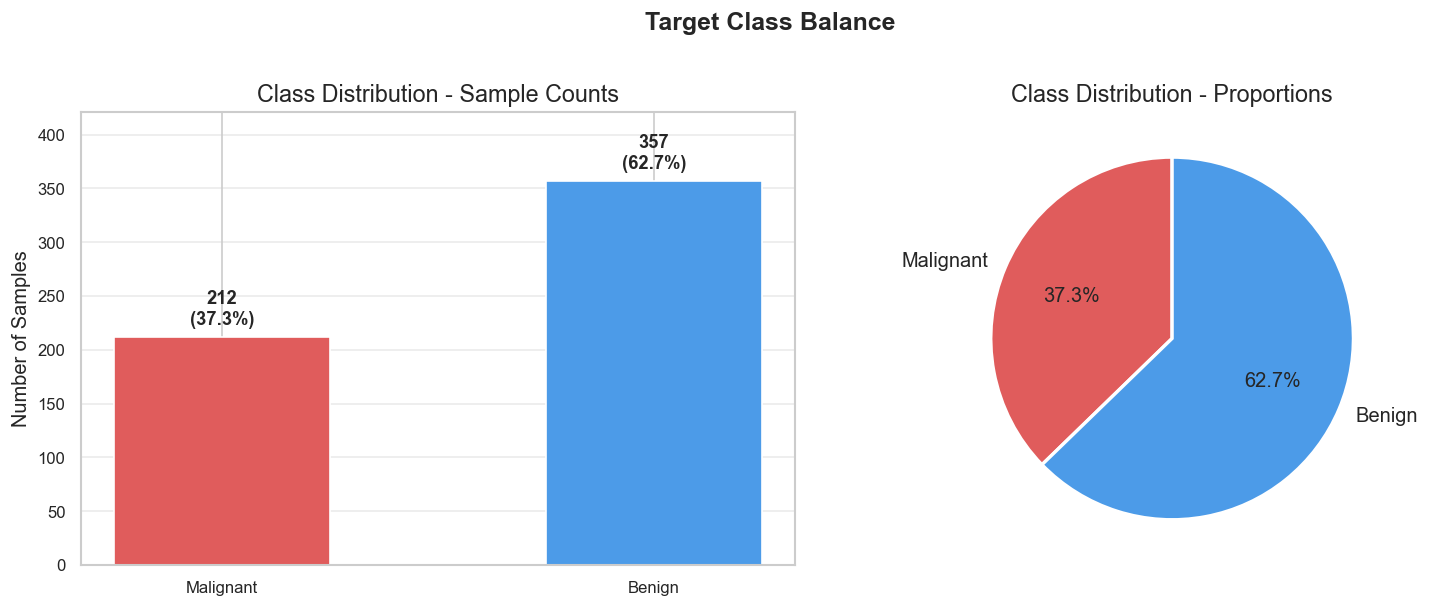

Saved: 01_class_distribution.png


In [8]:
# Visualizing class distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
bar_colors = [COLORS["malignant"], COLORS["benign"]]
bars = axes[0].bar(
    [label_map[0], label_map[1]],
    counts.values,
    color=bar_colors,
    width=0.5,
    edgecolor="white"
)
axes[0].set_title("Class Distribution - Sample Counts")
axes[0].set_ylabel("Number of Samples")
axes[0].set_ylim(0, counts.max() * 1.18)
for bar, val, pct in zip(bars, counts.values, percentages.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 8,
        f"{val}\n({pct:.1f}%)",
        ha="center", va="bottom", fontweight="bold", fontsize=11
    )
axes[0].grid(axis="y", alpha=0.4)

# Pie chart
axes[1].pie(
    counts.values,
    labels=[label_map[0], label_map[1]],
    colors=bar_colors,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    textprops={"fontsize": 12}
)
axes[1].set_title("Class Distribution - Proportions")

plt.suptitle("Target Class Balance", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/01_class_distribution.png", bbox_inches="tight")
plt.show()
print("Saved: 01_class_distribution.png")

### 2.5 Audit Summary

| Check | Result |
|---|---|
| Missing values | None |
| Duplicate rows | None |
| Feature data types | All float64 |
| Target classes | 2 (binary classification) |
| Class balance | Mild imbalance (~1.68:1 Benign to Malignant) |
| Feature scales | Highly varied, standardization required |

The dataset is clean and requires no imputation or deduplication. The mild
class imbalance does not warrant resampling, but we will use stratified
splitting and track recall for the malignant class closely throughout
evaluation, since missing a malignant case is the most costly type of error.

---
## Phase 3: Exploratory Data Analysis

Before we touch a single algorithm, we need to develop an intuition for
the data. Numbers alone do not tell the full story. Visualization reveals
things that summary statistics hide: which features separate the two classes
cleanly, which ones overlap completely, and where the interesting signal
actually lives.

We split this EDA into two parts. In this first part we focus on individual
feature distributions and how they behave differently for malignant versus
benign tumors. In Phase 4 we will look at how features relate to each other.

Three questions drive this section:

1. Do the distributions of individual features differ between classes?
2. Which features show the clearest separation between malignant and benign?
3. Are there extreme values that might influence model behavior?

### 3.1 Distribution of Mean Features

We have 30 features in total, organized into three groups: mean, error, and
worst. The mean features are the most intuitive starting point because they
represent the average measurement across all cell nuclei in a sample.

The histograms below show the overall distribution of each mean feature
across all 569 patients, regardless of class. This gives us a baseline sense
of the data's shape before we introduce the class dimension.

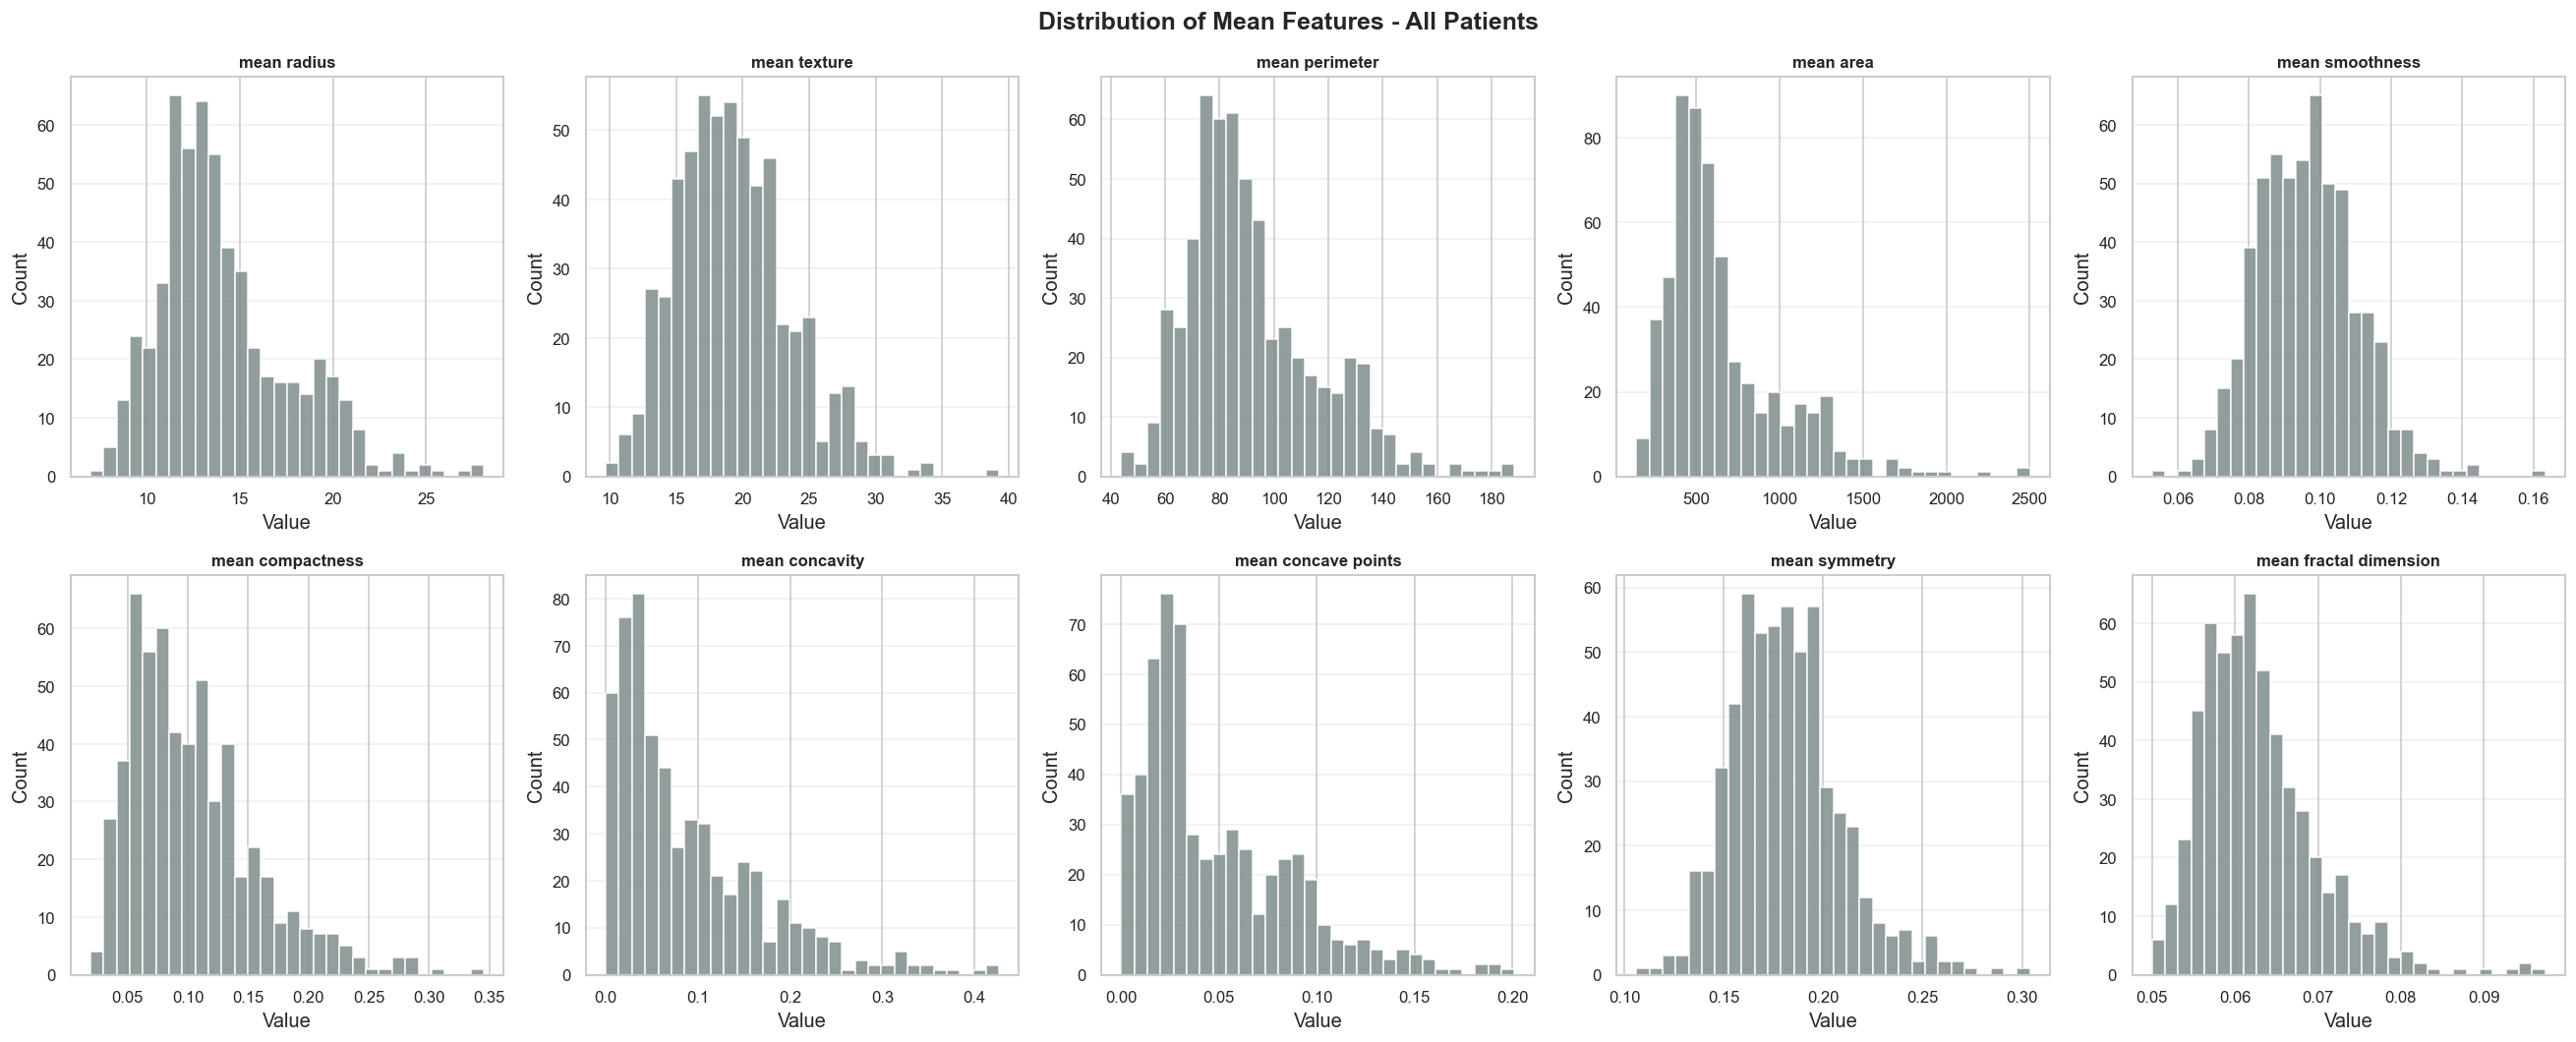

Saved: 02_mean_feature_distributions.png


In [9]:
mean_features = [col for col in df.columns if "mean" in col]

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.ravel()

for i, feature in enumerate(mean_features):
    axes[i].hist(
        df[feature], bins=30,
        color=COLORS["neutral"], edgecolor="white", alpha=0.85
    )
    axes[i].set_title(feature, fontsize=10, fontweight="bold")
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Count")
    axes[i].grid(axis="y", alpha=0.3)

plt.suptitle("Distribution of Mean Features - All Patients", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/02_mean_feature_distributions.png", bbox_inches="tight")
plt.show()
print("Saved: 02_mean_feature_distributions.png")

### 3.2 Malignant vs. Benign: Violin Plots

Histograms show the overall shape but collapse both classes into one picture.
To understand which features are actually useful for classification, we need
to see how each feature behaves separately for malignant and benign tumors.

Violin plots are ideal for this. They combine a box plot's summary statistics
with a smoothed estimate of the underlying distribution shape. A feature where
the two violins barely overlap is a strong candidate for driving predictions.
A feature where they sit on top of each other carries very little signal.

We focus on the six mean features most commonly cited in the clinical
literature on this dataset: radius, texture, perimeter, area, concavity,
and concave points.

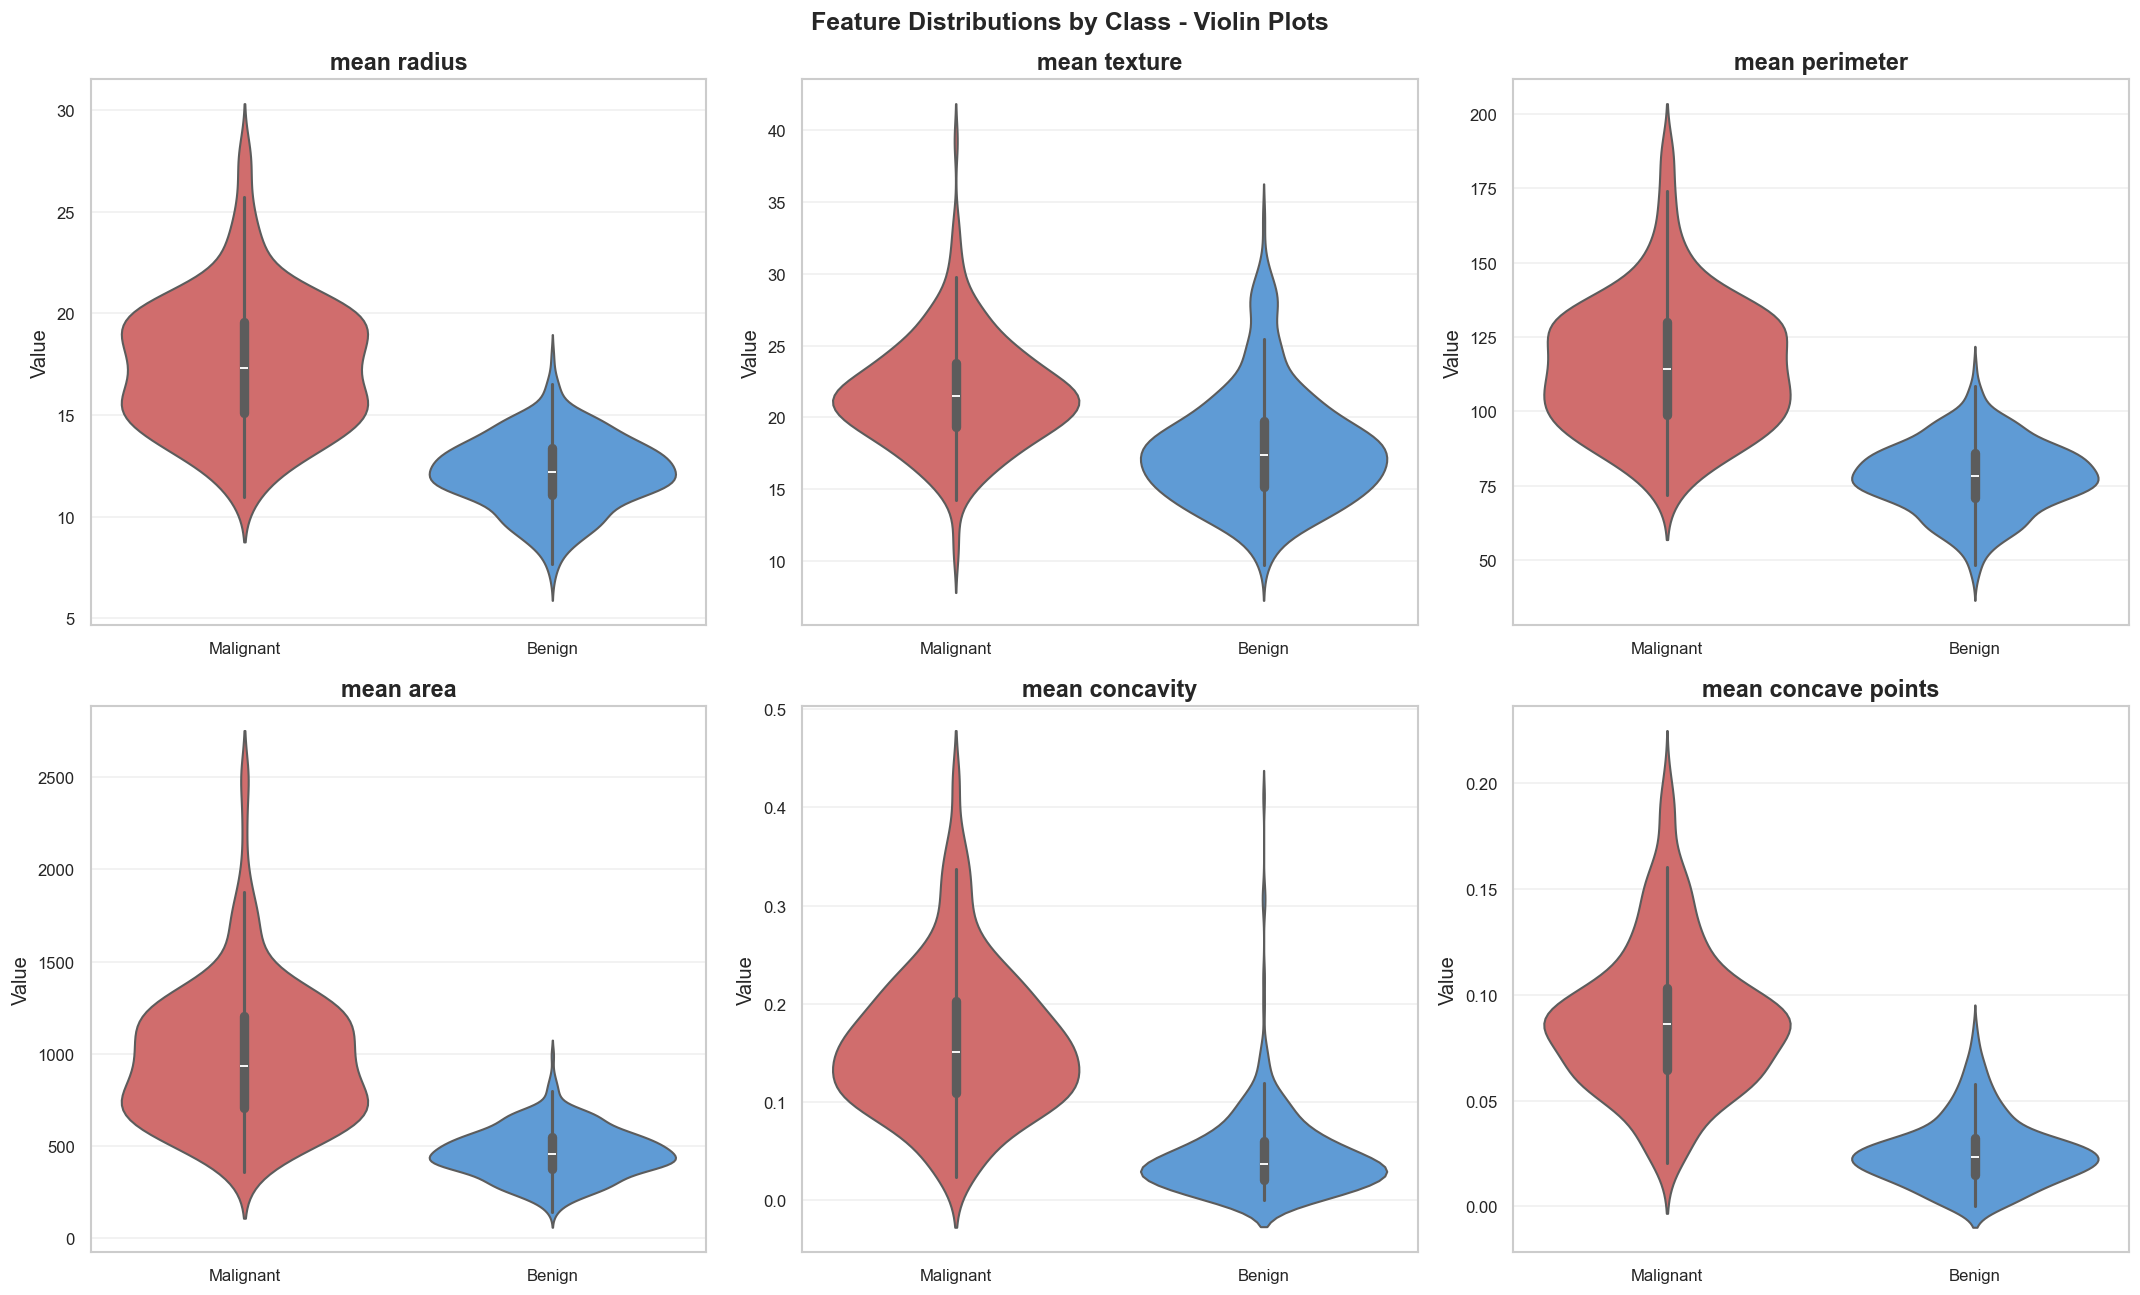

Saved: 03_violin_plots_by_class.png


In [10]:
key_features = [
    "mean radius", "mean texture", "mean perimeter",
    "mean area", "mean concavity", "mean concave points"
]

plot_df = df[key_features + ["target"]].copy()
plot_df["Class"] = plot_df["target"].map(label_map)

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.ravel()

for i, feature in enumerate(key_features):
    sns.violinplot(
        data=plot_df,
        x="Class", y=feature,
        palette={"Malignant": COLORS["malignant"], "Benign": COLORS["benign"]},
        inner="box",
        ax=axes[i]
    )
    axes[i].set_title(feature, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Value")
    axes[i].grid(axis="y", alpha=0.3)

plt.suptitle("Feature Distributions by Class - Violin Plots", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/03_violin_plots_by_class.png", bbox_inches="tight")
plt.show()
print("Saved: 03_violin_plots_by_class.png")

### 3.3 KDE Plots: Seeing the Overlap

Violin plots summarize the distribution but can obscure exactly where the
two classes overlap. Kernel Density Estimation (KDE) plots draw a smooth
probability curve for each class on the same axis. The area where the two
curves overlap is the region of ambiguity where the model will find it
hardest to make a correct decision.

A feature with two well-separated peaks is a clean signal. A feature where
the two curves nearly coincide is close to useless for classification.

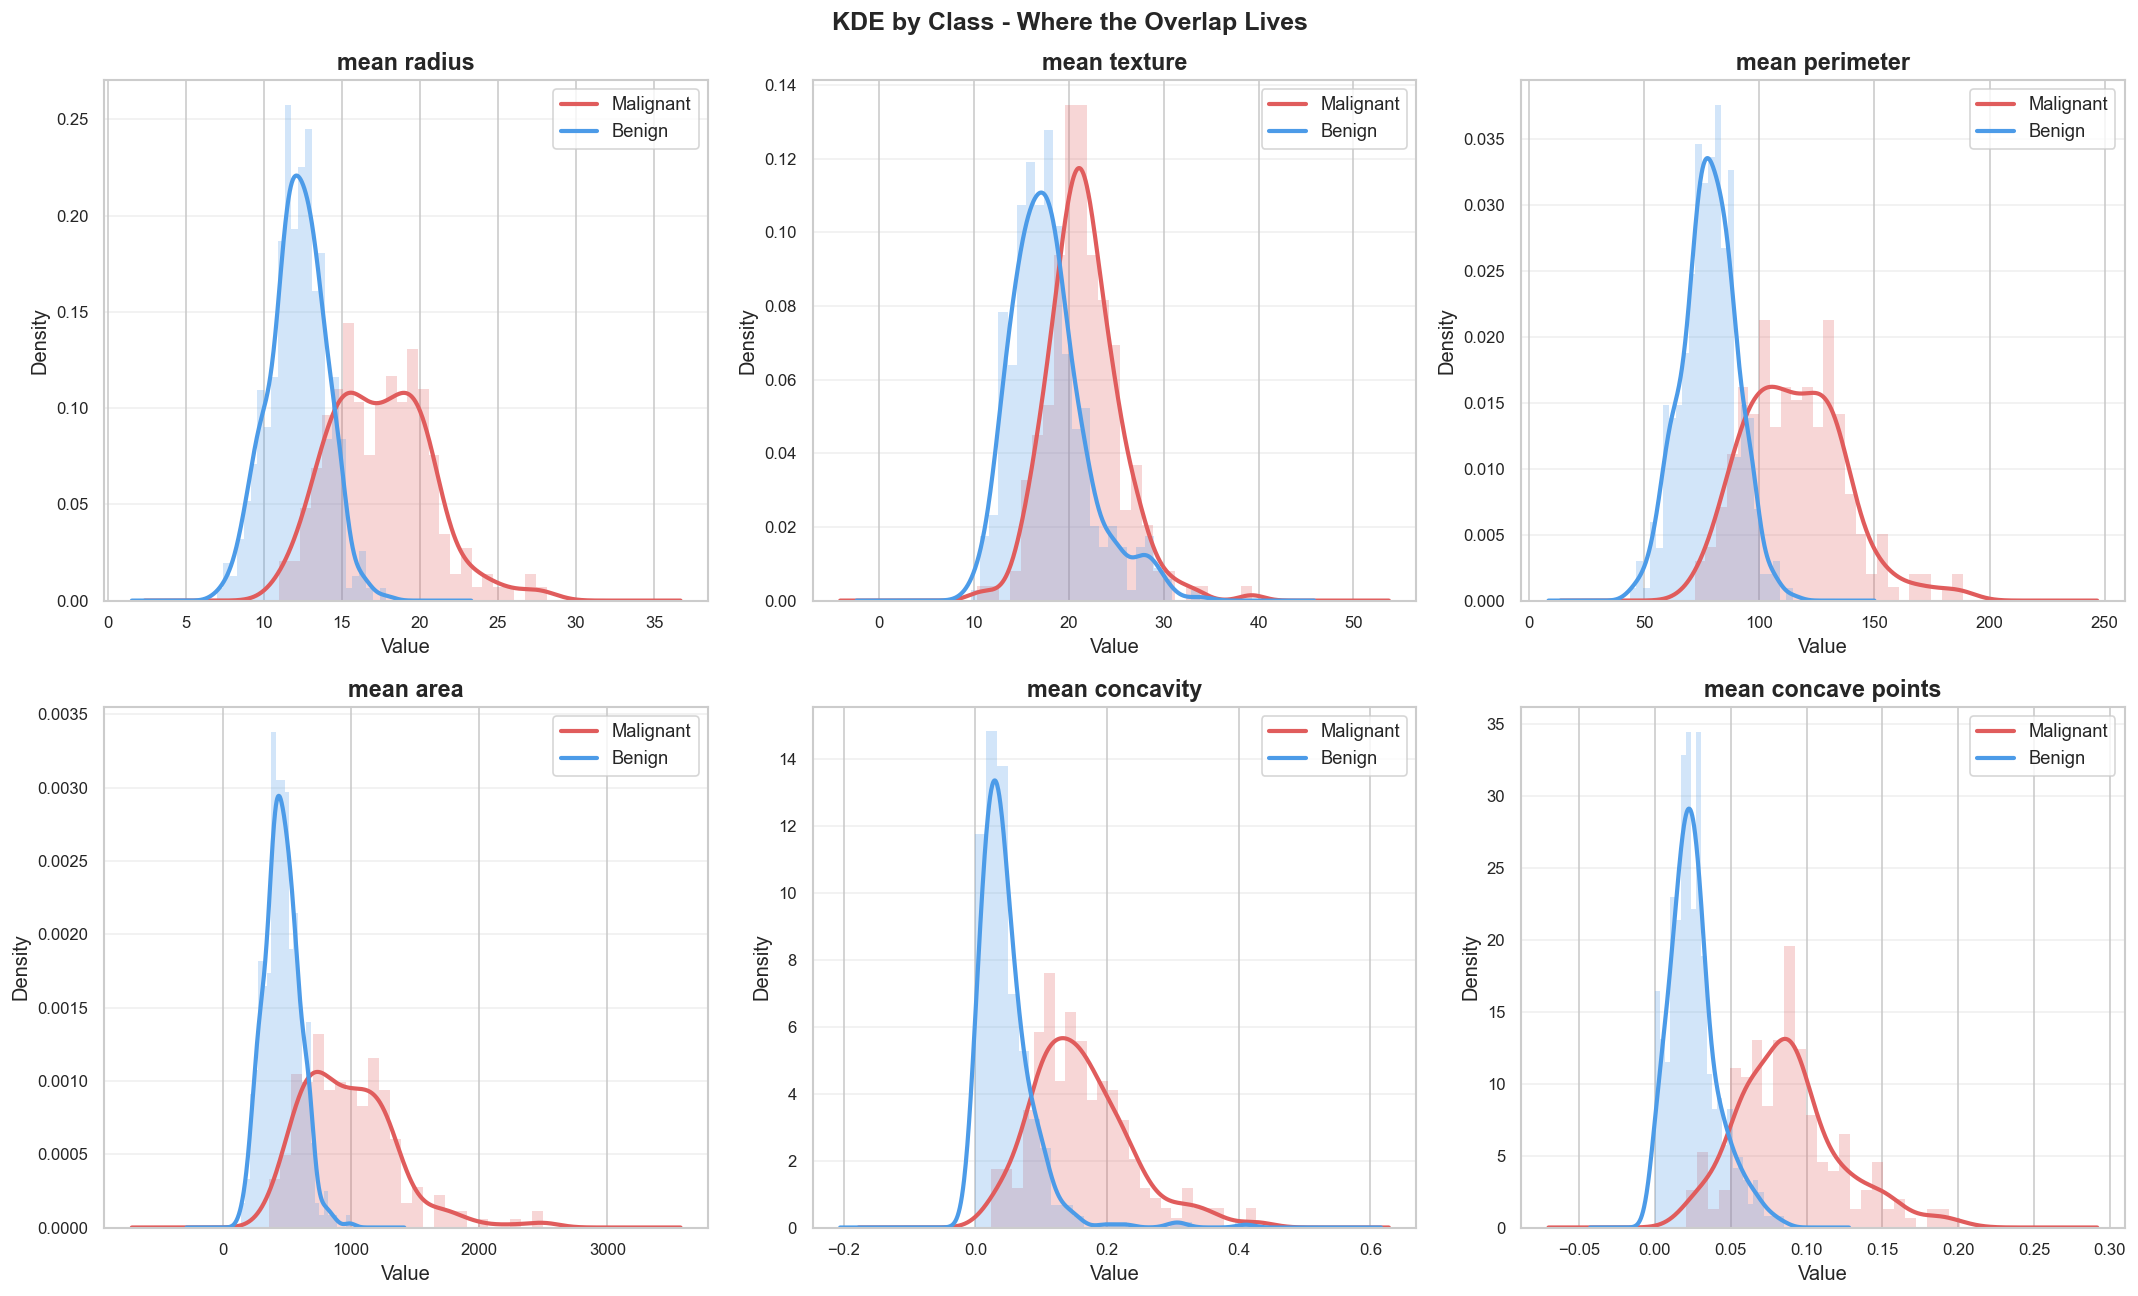

Saved: 04_kde_by_class.png


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.ravel()

for i, feature in enumerate(key_features):
    for cls, color, label in zip(
        [0, 1],
        [COLORS["malignant"], COLORS["benign"]],
        ["Malignant", "Benign"]
    ):
        subset = df[df["target"] == cls][feature]
        axes[i].hist(
            subset, bins=25, density=True,
            alpha=0.25, color=color, edgecolor="none"
        )
        subset.plot.kde(ax=axes[i], color=color, linewidth=2.5, label=label)

    axes[i].set_title(feature, fontweight="bold")
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Density")
    axes[i].legend()
    axes[i].grid(axis="y", alpha=0.3)

plt.suptitle("KDE by Class - Where the Overlap Lives", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/04_kde_by_class.png", bbox_inches="tight")
plt.show()
print("Saved: 04_kde_by_class.png")

### 3.4 Which Features Separate the Classes Best?

Looking at individual plots is useful but comparing 30 features one by one
is slow. A more efficient approach is to compute a separation score for every
feature at once and rank them.

We use a simple but effective measure: the absolute difference between the
class means, divided by the average standard deviation. This is sometimes
called the effect size. A large effect size means the two classes sit far
apart relative to their own spread, which generally makes a feature more
useful for a classifier.

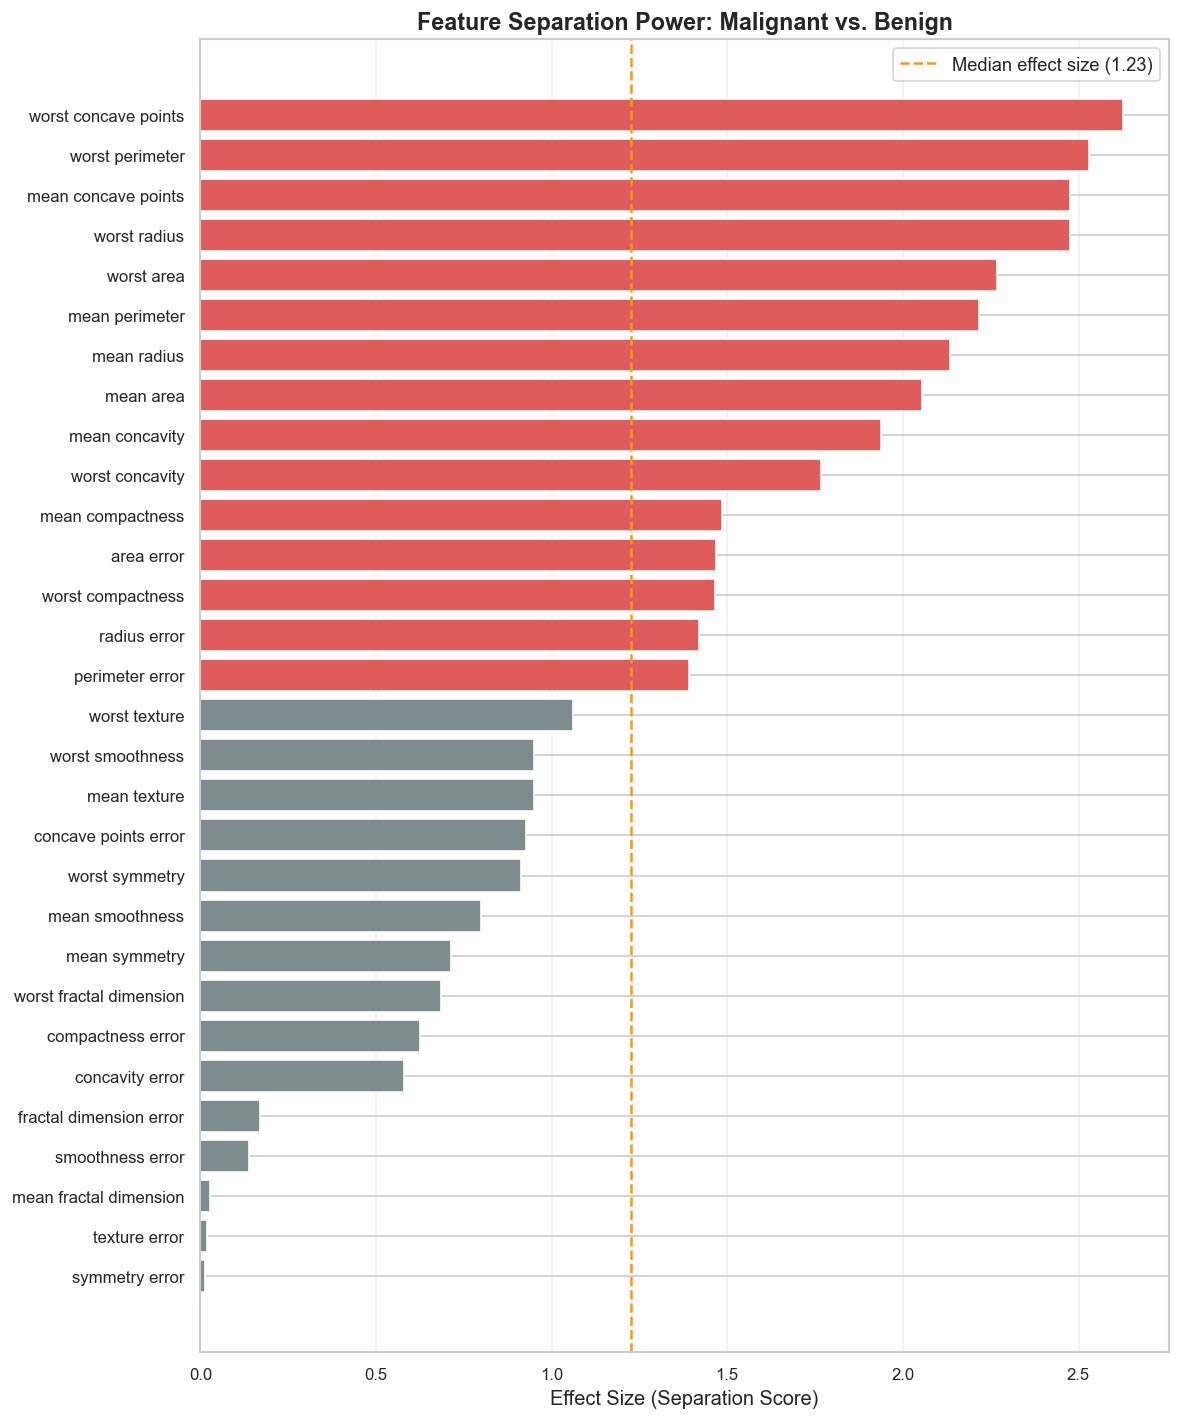

Saved: 05_feature_separation_scores.png


In [12]:
malignant_df = df[df["target"] == 0].drop("target", axis=1)
benign_df    = df[df["target"] == 1].drop("target", axis=1)

effect_size = (
    (malignant_df.mean() - benign_df.mean()).abs()
    / ((malignant_df.std() + benign_df.std()) / 2)
)
effect_size = effect_size.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 12))
bars = ax.barh(
    effect_size.index,
    effect_size.values,
    color=[
        COLORS["malignant"] if v > effect_size.median() else COLORS["neutral"]
        for v in effect_size.values
    ],
    edgecolor="white"
)
ax.axvline(effect_size.median(), color=COLORS["highlight"], linestyle="--",
           linewidth=1.5, label=f"Median effect size ({effect_size.median():.2f})")
ax.set_xlabel("Effect Size (Separation Score)")
ax.set_title("Feature Separation Power: Malignant vs. Benign", fontweight="bold", fontsize=14)
ax.legend()
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(f"{IMG_DIR}/05_feature_separation_scores.png", bbox_inches="tight")
plt.show()
print("Saved: 05_feature_separation_scores.png")

### 3.5 Key Findings from This Section

Several clear patterns emerge from the distributions:

- The **worst** group features (worst concave points, worst perimeter, worst radius)
  consistently show the strongest separation between classes. Extreme measurements
  in a sample appear to carry more diagnostic signal than average measurements.
- Features like **mean concavity** and **mean concave points** also separate
  the classes cleanly, reflecting the fact that malignant cells tend to have
  more irregular, jagged boundaries.
- **Mean texture** and **mean fractal dimension** show substantially more overlap,
  meaning they contribute less individually to distinguishing the two classes.
- In every informative feature, malignant tumors sit higher on the scale.
  They are larger, more irregular, and more asymmetric than benign ones.

These findings will help us interpret feature importance scores once the
models are trained.

---

## Phase 4: EDA - Correlations and Feature Relationships

In the previous section we looked at each feature in isolation. Now we
take a step back and ask how the features relate to each other.

This matters for two reasons. First, highly correlated features carry
redundant information. Knowing both the radius and the perimeter of a circle
adds almost nothing, because one is mathematically tied to the other. Second,
understanding the correlation structure helps explain model behavior later.
If a model leans heavily on one feature, it may effectively be capturing
the signal from several correlated ones at the same time.

We explore three things in this section:

1. The full correlation matrix across all 30 features
2. The specific feature pairs with the strongest linear relationships
3. A pair plot of the top features to see class separation in two dimensions

### 4.1 Full Correlation Matrix

A correlation coefficient ranges from -1 to 1. Values close to 1 mean the
two features move together. Values close to -1 mean they move in opposite
directions. Values near 0 mean no linear relationship.

The heatmap below shows every pairwise correlation across all 30 features.
Red indicates strong positive correlation, blue indicates negative correlation,
and white indicates little to no linear relationship.

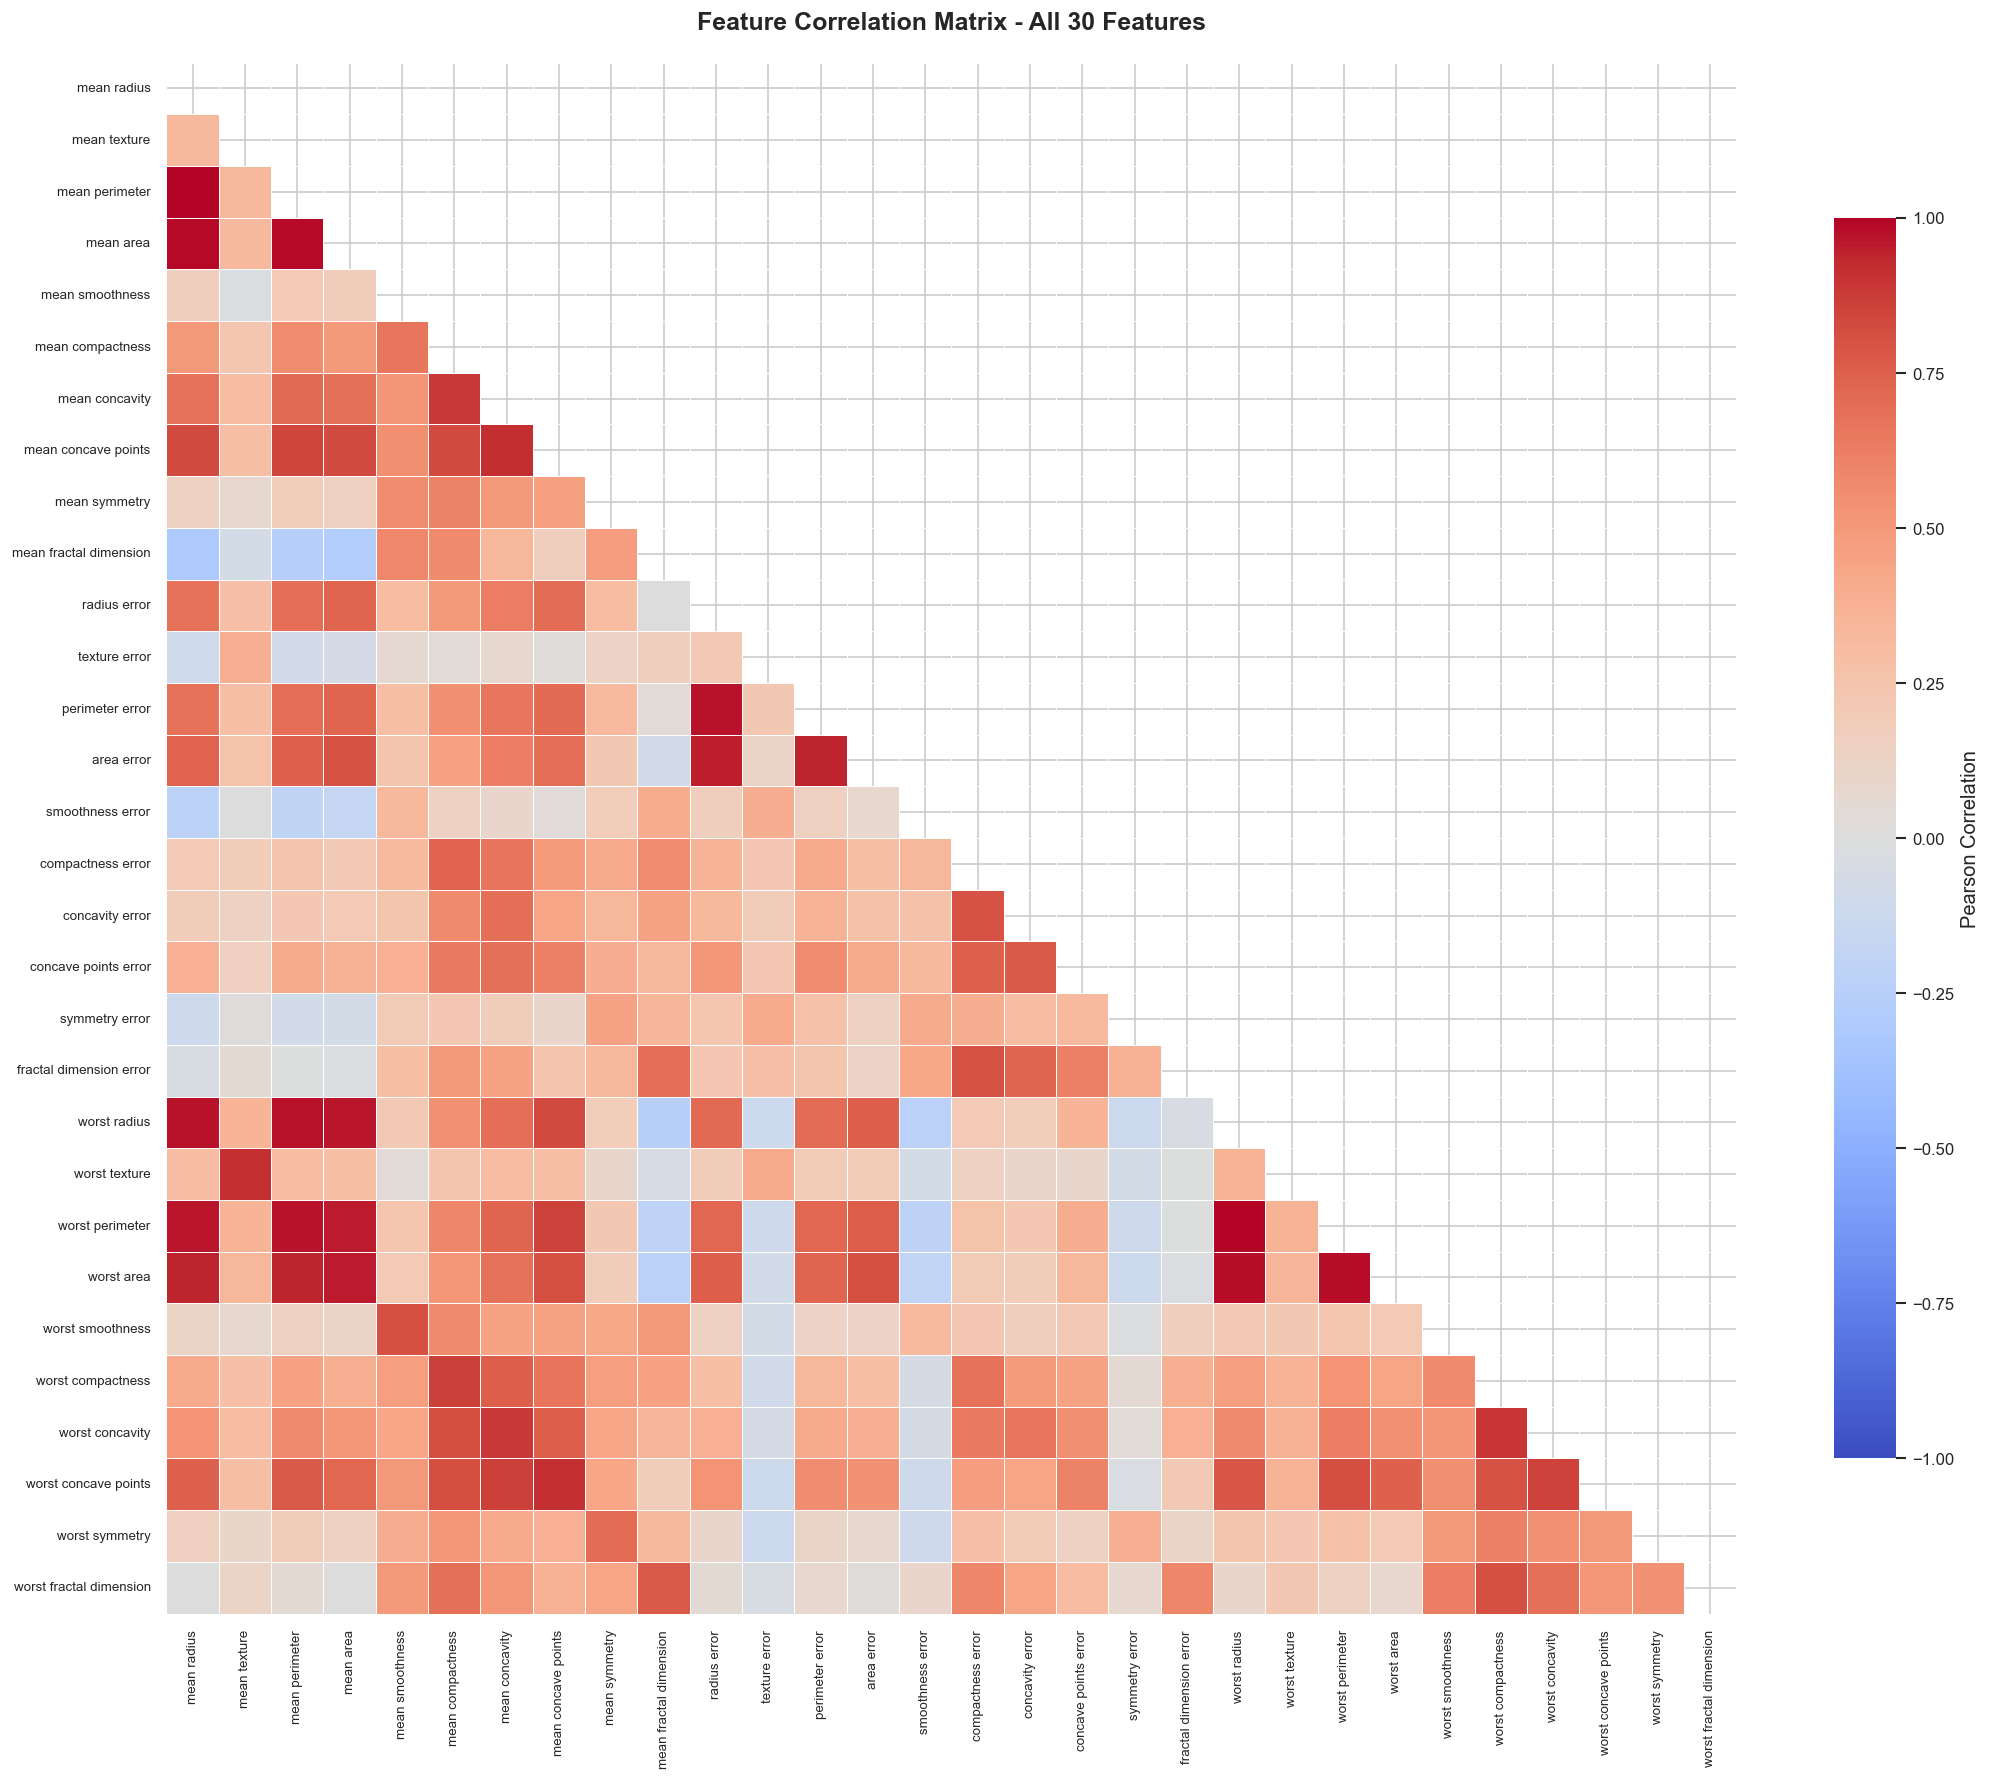

Saved: 06_correlation_matrix.png


In [13]:
corr_matrix = df.drop("target", axis=1).corr()

fig, ax = plt.subplots(figsize=(18, 15))

mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.3,
    linecolor="white",
    annot=False,
    cbar_kws={"shrink": 0.8, "label": "Pearson Correlation"},
    ax=ax
)

ax.set_title("Feature Correlation Matrix - All 30 Features", fontsize=15, fontweight="bold", pad=20)
ax.tick_params(axis="x", rotation=90, labelsize=8)
ax.tick_params(axis="y", rotation=0, labelsize=8)

plt.tight_layout()
plt.savefig(f"{IMG_DIR}/06_correlation_matrix.png", bbox_inches="tight")
plt.show()
print("Saved: 06_correlation_matrix.png")

### 4.2 Identifying Highly Correlated Feature Pairs

The heatmap gives a broad overview, but it is hard to read exact values from
color alone. Here we extract every feature pair with a correlation above 0.90
and rank them from strongest to weakest.

These pairs are worth knowing because including both features in a model adds
little information while increasing complexity. Tree-based models handle
this naturally, but distance-based models like KNN and SVM can be affected.

In [14]:
# Extract upper triangle pairs only to avoid duplicates
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.90:
            high_corr_pairs.append({
                "Feature A":   corr_matrix.columns[i],
                "Feature B":   corr_matrix.columns[j],
                "Correlation": round(val, 4)
            })

high_corr_df = (
    pd.DataFrame(high_corr_pairs)
    .sort_values("Correlation", ascending=False)
    .reset_index(drop=True)
)

print(f"Feature pairs with |correlation| > 0.90: {len(high_corr_df)}\n")
print(high_corr_df.to_string(index=False))

Feature pairs with |correlation| > 0.90: 21

          Feature A            Feature B  Correlation
        mean radius       mean perimeter       0.9979
       worst radius      worst perimeter       0.9937
        mean radius            mean area       0.9874
     mean perimeter            mean area       0.9865
       worst radius           worst area       0.9840
    worst perimeter           worst area       0.9776
       radius error      perimeter error       0.9728
     mean perimeter      worst perimeter       0.9704
        mean radius         worst radius       0.9695
     mean perimeter         worst radius       0.9695
        mean radius      worst perimeter       0.9651
          mean area         worst radius       0.9627
          mean area           worst area       0.9592
          mean area      worst perimeter       0.9591
       radius error           area error       0.9518
     mean perimeter           worst area       0.9415
        mean radius           worst a

### 4.3 Correlation with the Target

The correlation matrix above only covers feature-to-feature relationships.
It is equally useful to know which features have the strongest linear
relationship with the target variable itself.

A high positive correlation with the target means higher values of that
feature tend to correspond to benign cases. A high negative correlation
means higher values tend to correspond to malignant cases. Features close
to zero are linearly unrelated to the outcome, though they may still carry
non-linear signal that tree-based models can exploit.

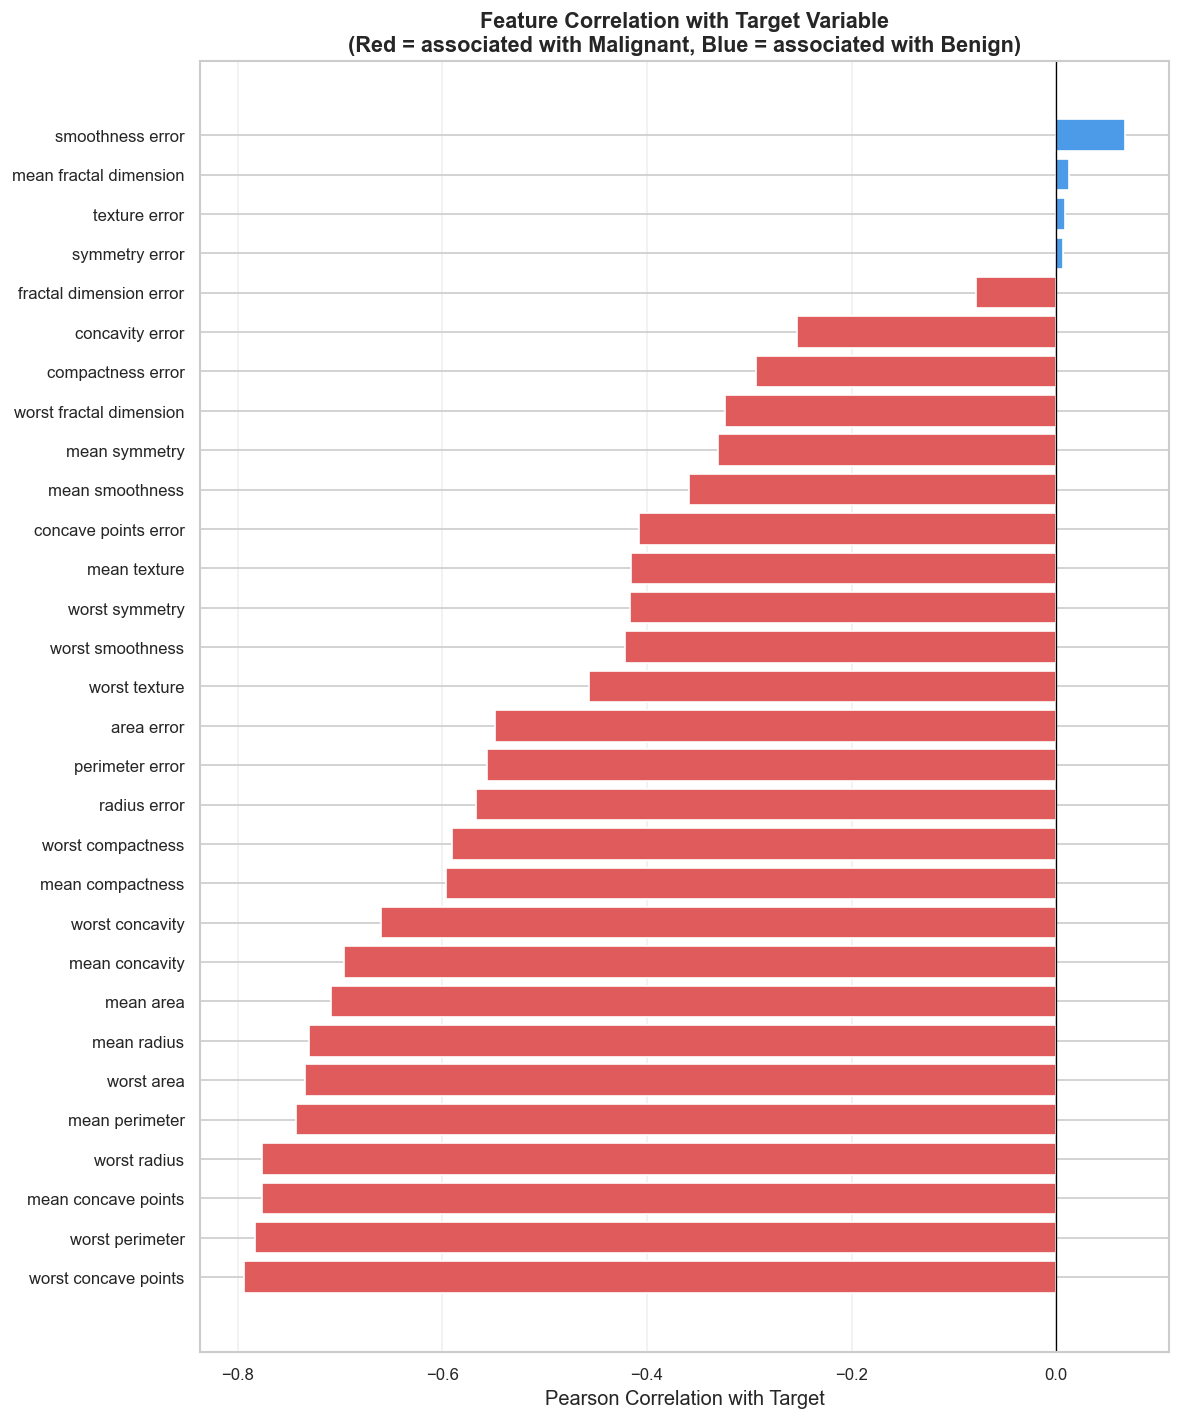

Saved: 07_target_correlation.png


In [15]:
target_corr = (
    df.corr()["target"]
    .drop("target")
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 12))

colors = [
    COLORS["malignant"] if v < 0 else COLORS["benign"]
    for v in target_corr.values
]

ax.barh(target_corr.index, target_corr.values, color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Pearson Correlation with Target")
ax.set_title("Feature Correlation with Target Variable\n(Red = associated with Malignant, Blue = associated with Benign)",
             fontweight="bold", fontsize=13)
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(f"{IMG_DIR}/07_target_correlation.png", bbox_inches="tight")
plt.show()
print("Saved: 07_target_correlation.png")

### 4.4 Pair Plot of the Top Separating Features

A pair plot places every combination of selected features on a grid. The
diagonal shows each feature's distribution split by class. The off-diagonal
cells show scatter plots of one feature against another, colored by class.

We select the four features with the strongest separation scores from Phase 3.
If those four features cluster well by class in two-dimensional space, a
classifier should have a relatively straightforward time separating them in
the full 30-dimensional feature space.

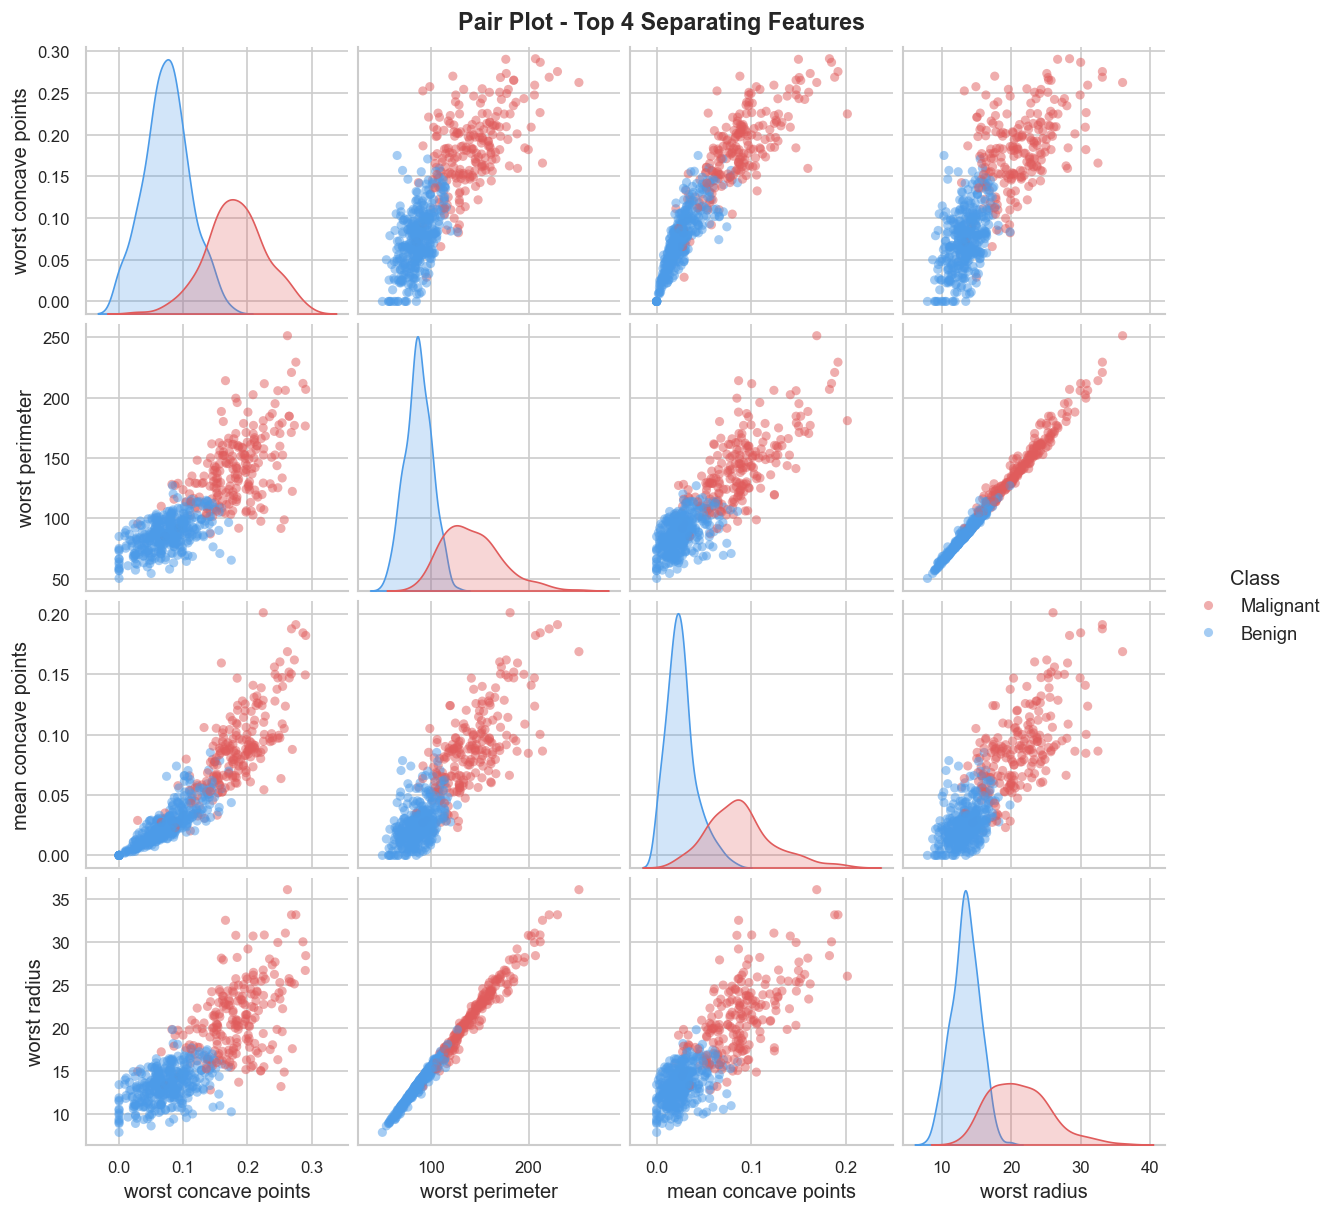

Saved: 08_pair_plot_top_features.png


In [16]:
top4 = effect_size.sort_values(ascending=False).head(4).index.tolist()

pair_df = df[top4 + ["target"]].copy()
pair_df["Class"] = pair_df["target"].map(label_map)

pair_grid = sns.pairplot(
    pair_df,
    hue="Class",
    vars=top4,
    palette={"Malignant": COLORS["malignant"], "Benign": COLORS["benign"]},
    plot_kws={"alpha": 0.5, "s": 30, "edgecolor": "none"},
    diag_kind="kde",
    corner=False
)

pair_grid.figure.suptitle(
    "Pair Plot - Top 4 Separating Features",
    fontsize=14, fontweight="bold", y=1.01
)

pair_grid.savefig(f"{IMG_DIR}/08_pair_plot_top_features.png", bbox_inches="tight")
plt.show()
print("Saved: 08_pair_plot_top_features.png")

### 4.5 Key Findings from This Section

The correlation analysis reveals a clear and interpretable structure in the data:

- **21 feature pairs exceed a correlation of 0.90**, confirming substantial
  redundancy in the dataset. The strongest relationship is between mean radius
  and mean perimeter at 0.9979, which is nearly a perfect linear relationship.
  This is geometrically expected since perimeter is a direct function of radius.
- **Radius, perimeter, and area form a tightly coupled group** across all three
  measurement levels (mean, error, worst). Feeding all of them into a
  distance-sensitive model like KNN or SVM adds almost no new information while
  increasing the feature space unnecessarily.
- **The four features with the strongest separation from Phase 3** are worst
  concave points, worst perimeter, mean concave points, and worst radius. The
  pair plot confirms that even in two dimensions these four features produce
  well-separated clusters, with malignant cases consistently occupying higher
  values on every axis.
- **The features most strongly correlated with a malignant outcome** are worst
  concave points, worst perimeter, and worst radius. Features like smoothness
  error, mean fractal dimension, and texture error sit near zero, meaning they
  carry very little linear signal for the target.

We now have a thorough understanding of both the individual features and their
relationships. The next step is to prepare the data for modeling.

---

## Phase 5: Preprocessing and Train-Test Split

With a solid understanding of the data, we can now prepare it for modeling.
This phase has two responsibilities: splitting the data honestly and scaling
the features correctly.

The order in which we do these two things is not a stylistic choice. It is
a correctness requirement. Scaling before splitting is one of the most common
mistakes in machine learning projects, and it produces results that look
better than they actually are. We will explain why as we go through each step.

### 5.1 Separating Features and Target

The first step is straightforward. We separate the DataFrame into a feature
matrix X containing all 30 measurements and a target vector y containing
the class labels. Every subsequent step in the pipeline operates on these
two objects.

In [17]:
X = df.drop("target", axis=1)
y = df["target"]

print("FEATURE MATRIX AND TARGET VECTOR")
print(f"  X shape: {X.shape}  ({X.shape[0]} samples, {X.shape[1]} features)")
print(f"  y shape: {y.shape}  ({y.value_counts()[0]} malignant, {y.value_counts()[1]} benign)")

FEATURE MATRIX AND TARGET VECTOR
  X shape: (569, 30)  (569 samples, 30 features)
  y shape: (569,)  (212 malignant, 357 benign)


### 5.2 Train-Test Split

We divide the data into a training set and a test set using an 80/20 split.
The training set is what every model will learn from. The test set is locked
away and will not be touched until the final evaluation phase.

Two details matter here:

**Stratification:** We pass `stratify=y` to ensure that both sets contain
the same proportion of malignant and benign cases as the original dataset.
Without this, a random split might accidentally place most malignant cases
in one set and leave the other with an unrepresentative sample.

**Random state:** Setting `random_state=42` makes the split reproducible.
Anyone running this notebook will get the exact same training and test sets,
which means results are comparable and verifiable.

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("TRAIN-TEST SPLIT")
print(f"  Training set:  {X_train.shape[0]} samples ({X_train.shape[0] / len(X) * 100:.1f}%)")
print(f"  Test set:      {X_test.shape[0]} samples  ({X_test.shape[0] / len(X) * 100:.1f}%)")
print(f"\nSTRATIFICATION CHECK")
for label, name in label_map.items():
    train_pct = (y_train == label).sum() / len(y_train) * 100
    test_pct  = (y_test  == label).sum() / len(y_test)  * 100
    orig_pct  = (y       == label).sum() / len(y)       * 100
    print(f"  {name}: original {orig_pct:.1f}%  |  train {train_pct:.1f}%  |  test {test_pct:.1f}%")

TRAIN-TEST SPLIT
  Training set:  455 samples (80.0%)
  Test set:      114 samples  (20.0%)

STRATIFICATION CHECK
  Malignant: original 37.3%  |  train 37.4%  |  test 36.8%
  Benign: original 62.7%  |  train 62.6%  |  test 63.2%


### 5.3 Feature Scaling

Our EDA showed that features operate on very different numeric scales.
Mean area reaches values above 2500 while mean fractal dimension stays
below 0.20. Algorithms that compute distances or rely on gradient-based
optimization treat a difference of 1.0 the same regardless of the feature
it comes from. A one-unit change in mean area is trivial. A one-unit change
in mean fractal dimension does not even exist in the data.

We use StandardScaler, which transforms each feature to have a mean of zero
and a standard deviation of one:

    x_scaled = (x - mean) / std

**Why we fit only on training data:**
The scaler needs to compute the mean and standard deviation of each feature
to perform this transformation. If we fit it on the full dataset before
splitting, the test set's statistics leak into the training process. The
model would have indirectly seen information about the test set during
preparation, making the final evaluation score an overestimate of real
performance. We fit the scaler on training data only, then apply the same
transformation to the test set using those training statistics.

In [19]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X.columns)

print("SCALING APPLIED")
print(f"  Scaler fitted on training set only ({X_train.shape[0]} samples)")
print(f"\nBEFORE SCALING - First 5 features (training set)")
print(X_train.iloc[:, :5].describe().loc[["mean", "std", "min", "max"]].round(4).to_string())
print(f"\nAFTER SCALING - First 5 features (training set)")
print(X_train_scaled.iloc[:, :5].describe().loc[["mean", "std", "min", "max"]].round(4).to_string())

SCALING APPLIED
  Scaler fitted on training set only (455 samples)

BEFORE SCALING - First 5 features (training set)
      mean radius  mean texture  mean perimeter  mean area  mean smoothness
mean      14.0672       19.2474         91.5574   648.5411           0.0962
std        3.4994        4.4053         24.1492   344.9446           0.0135
min        6.9810        9.7100         43.7900   143.5000           0.0625
max       28.1100       39.2800        188.5000  2499.0000           0.1447

AFTER SCALING - First 5 features (training set)
      mean radius  mean texture  mean perimeter  mean area  mean smoothness
mean      -0.0000        0.0000         -0.0000     0.0000           0.0000
std        1.0011        1.0011          1.0011     1.0011           1.0011
min       -2.0272       -2.1674         -1.9802    -1.4657          -2.5037
max        4.0174        4.5524          4.0187     5.3704           3.6103


### 5.4 Visual Confirmation of Scaling

Numbers confirm that the transformation worked mathematically. A visual
comparison makes it easier to see the practical effect. Before scaling,
the box plots sit on completely different vertical ranges, making meaningful
comparison impossible. After scaling, every feature shares the same axis
and can be compared directly.

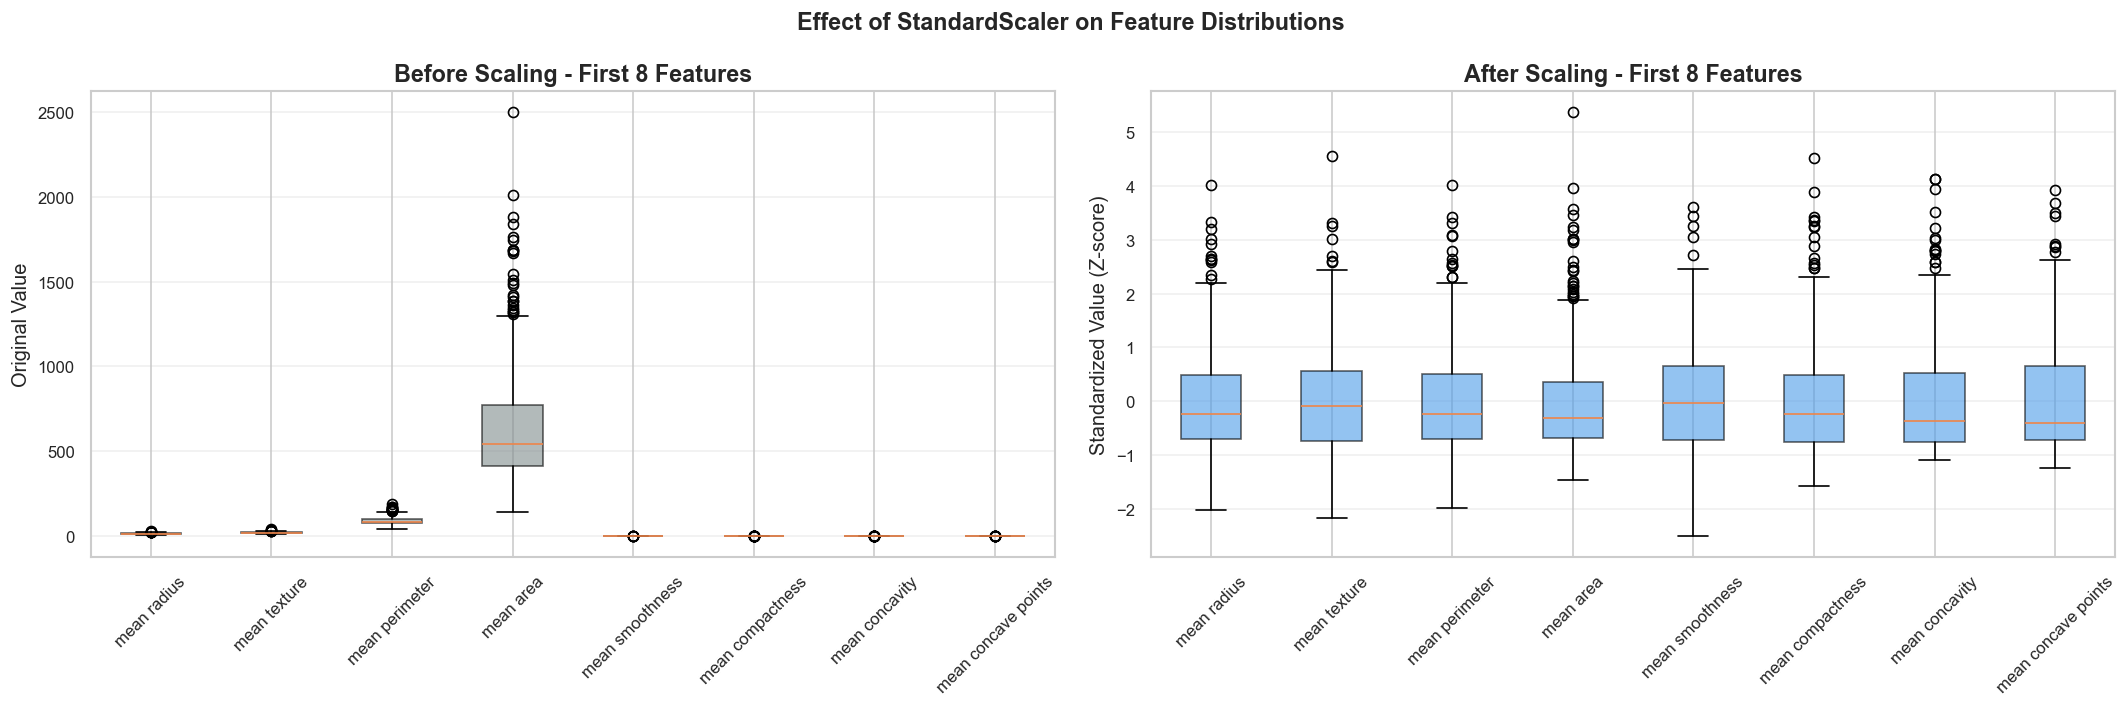

Saved: 09_scaling_comparison.png


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

features_to_show = X_train.columns[:8]

axes[0].boxplot(
    [X_train[f].values for f in features_to_show],
    labels=features_to_show,
    patch_artist=True,
    boxprops=dict(facecolor=COLORS["neutral"], alpha=0.6)
)
axes[0].set_title("Before Scaling - First 8 Features", fontweight="bold")
axes[0].set_ylabel("Original Value")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(axis="y", alpha=0.3)

axes[1].boxplot(
    [X_train_scaled[f].values for f in features_to_show],
    labels=features_to_show,
    patch_artist=True,
    boxprops=dict(facecolor=COLORS["benign"], alpha=0.6)
)
axes[1].set_title("After Scaling - First 8 Features", fontweight="bold")
axes[1].set_ylabel("Standardized Value (Z-score)")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("Effect of StandardScaler on Feature Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/09_scaling_comparison.png", bbox_inches="tight")
plt.show()
print("Saved: 09_scaling_comparison.png")

### 5.5 Preprocessing Summary

The data is now ready for modeling. Here is a summary of every decision
made in this phase and the reasoning behind each one:

| Decision | Choice | Reason |
|---|---|---|
| Split ratio | 80% train, 20% test | Standard split for a dataset of this size |
| Stratification | Enabled | Preserves class proportions in both sets |
| Random state | 42 | Reproducibility across runs |
| Scaling method | StandardScaler | Required for SVM, KNN, and Logistic Regression |
| Scaler fit | Training set only | Prevents data leakage into the test set |
| Missing value handling | None required | Dataset has zero missing values |

In the next phase we train six different algorithms on the same training
data and compare their out-of-the-box performance as a starting point.

---

## Phase 6: Multi-Model Baseline Comparison

Most machine learning projects train one model and stop there. That approach
has a fundamental problem: you have no way of knowing whether the model you
chose was actually the right tool for this problem, or whether a different
algorithm would have performed significantly better with the same data.

In this phase we train six algorithms on identical data under identical
conditions and compare their out-of-the-box performance. No tuning, no
tricks. The goal is to establish honest baselines and identify which
algorithms are worth investing time in during the tuning phase.

The six algorithms cover a broad range of learning strategies:

| Model | Strategy |
|---|---|
| Logistic Regression | Linear decision boundary, probability-based |
| Decision Tree | Recursive binary splits on single features |
| Random Forest | Ensemble of many decorrelated trees |
| K-Nearest Neighbors | Classifies based on proximity to training samples |
| Support Vector Machine | Finds the maximum-margin hyperplane between classes |
| Gaussian Naive Bayes | Probabilistic model assuming feature independence |

Running all six gives us a performance landscape rather than a single number
to evaluate.## Phase 6: Multi-Model Baseline Comparison


### 6.1 Defining the Models

We define all six models in a single dictionary so they can be trained and
evaluated in a loop. Every model uses the same random state where applicable
to ensure that any differences in performance come from the algorithm itself,
not from randomness in initialization.

In [21]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=10000, random_state=RANDOM_STATE
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, random_state=RANDOM_STATE
    ),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Support Vector Machine": SVC(
        probability=True, random_state=RANDOM_STATE
    ),
    "Naive Bayes": GaussianNB()
}

print(f"{len(models)} models registered and ready for training.")
for name in models:
    print(f"  {name}")

6 models registered and ready for training.
  Logistic Regression
  Decision Tree
  Random Forest
  K-Nearest Neighbors
  Support Vector Machine
  Naive Bayes


### 6.2 Training and Evaluating All Models

Each model is trained on the scaled training set and evaluated on the scaled
test set. We record four metrics for every model:

- **Accuracy:** The proportion of all predictions that were correct.
- **Precision:** Of the cases predicted malignant, how many actually were.
- **Recall:** Of all actual malignant cases, how many the model caught.
- **F1-Score:** The harmonic mean of precision and recall. This is our
  primary ranking metric because it balances both error types.

In a medical context, recall for the malignant class deserves the most
attention. A missed cancer case is a far more serious error than an
unnecessary follow-up appointment. We track it explicitly alongside the
aggregate metrics.

In [23]:
results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    results.append({
        "Model":     name,
        "Accuracy":  accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall":    recall_score(y_test, y_pred, zero_division=0),
        "F1-Score":  f1_score(y_test, y_pred, zero_division=0),
        "Recall (Malignant)": recall_score(
            y_test, y_pred, pos_label=0, zero_division=0
        )
    })
    print(f"  Trained: {name}")

results_df = pd.DataFrame(results).sort_values("F1-Score", ascending=False).reset_index(drop=True)

print("\nBASELINE RESULTS - Ranked by F1-Score")
print(results_df.to_string(index=False))

  Trained: Logistic Regression
  Trained: Decision Tree
  Trained: Random Forest
  Trained: K-Nearest Neighbors
  Trained: Support Vector Machine
  Trained: Naive Bayes

BASELINE RESULTS - Ranked by F1-Score
                 Model  Accuracy  Precision   Recall  F1-Score  Recall (Malignant)
   Logistic Regression  0.982456   0.986111 0.986111  0.986111            0.976190
Support Vector Machine  0.982456   0.986111 0.986111  0.986111            0.976190
   K-Nearest Neighbors  0.956140   0.958904 0.972222  0.965517            0.928571
         Random Forest  0.956140   0.958904 0.972222  0.965517            0.928571
           Naive Bayes  0.929825   0.944444 0.944444  0.944444            0.904762
         Decision Tree  0.912281   0.955882 0.902778  0.928571            0.928571


### 6.3 Visual Comparison

Numbers in a table are precise but hard to scan quickly. The bar chart
below plots all four metrics side by side for each model, making it
straightforward to see where each algorithm is strong and where it
gives up ground.

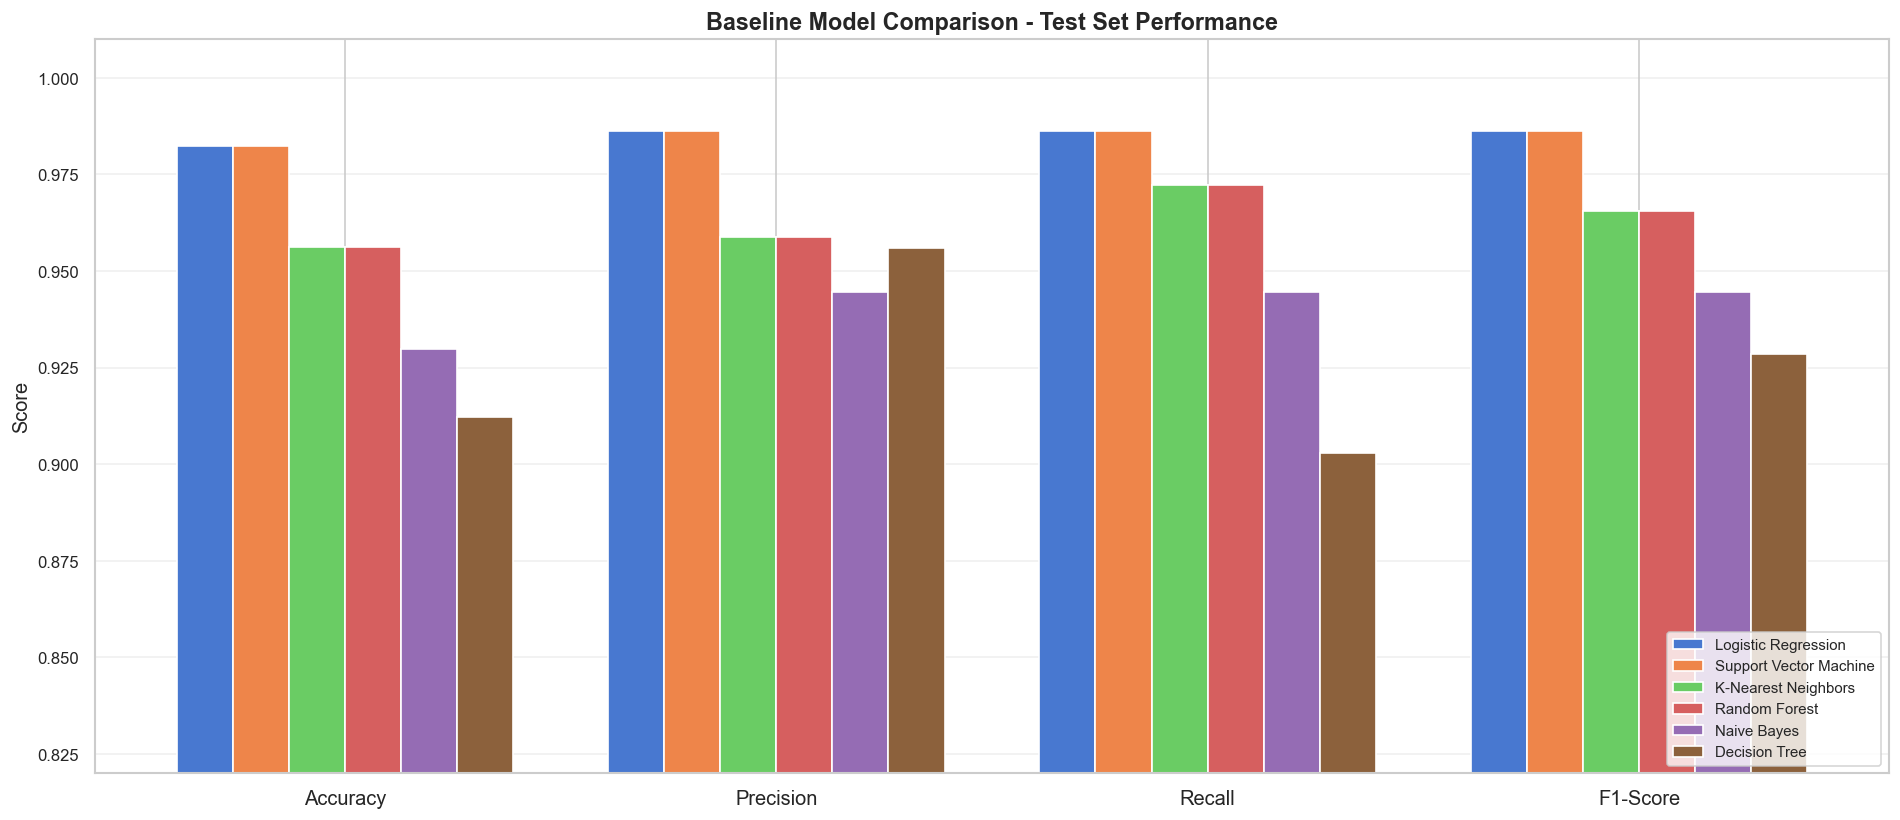

Saved: 10_baseline_model_comparison.png


In [24]:
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
x = np.arange(len(metrics))
width = 0.13
n = len(results_df)

palette = sns.color_palette("muted", n)

fig, ax = plt.subplots(figsize=(16, 7))

for i, (_, row) in enumerate(results_df.iterrows()):
    offset = (i - n / 2) * width + width / 2
    bars = ax.bar(
        x + offset,
        [row[m] for m in metrics],
        width=width,
        label=row["Model"],
        color=palette[i],
        edgecolor="white"
    )

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylabel("Score")
ax.set_ylim(0.82, 1.01)
ax.set_title("Baseline Model Comparison - Test Set Performance", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(f"{IMG_DIR}/10_baseline_model_comparison.png", bbox_inches="tight")
plt.show()
print("Saved: 10_baseline_model_comparison.png")

### 6.4 Malignant Recall - The Critical Metric

The aggregate F1-Score tells us how well a model performs overall. But
in this problem, the two error types are not equally costly.

A false negative means a malignant tumor was classified as benign. The
patient may not receive timely treatment. A false positive means a benign
tumor was flagged as suspicious. The patient undergoes additional testing,
which is stressful but recoverable.

Given that asymmetry, we isolate recall for the malignant class specifically
and rank every model on that metric alone. A model that scores well on
overall F1 but poorly on malignant recall is not a good candidate for
clinical use regardless of its headline number.

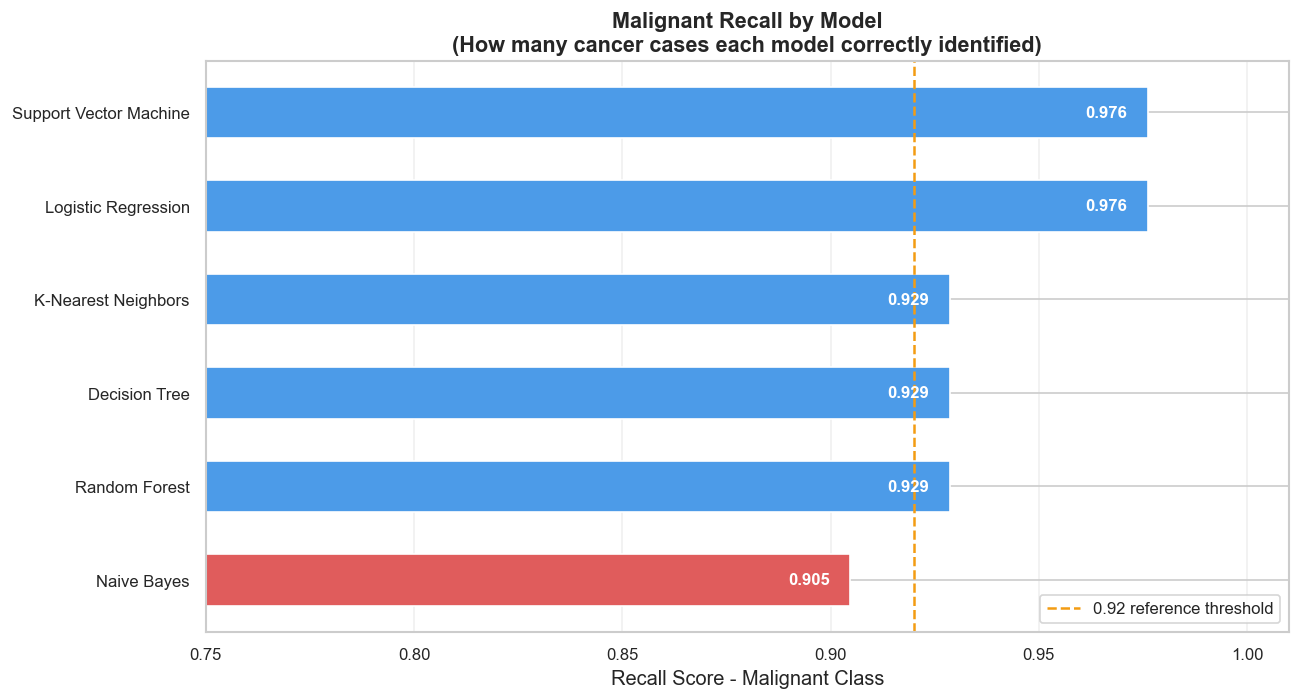

Saved: 11_malignant_recall_comparison.png


In [25]:
recall_df = results_df[["Model", "Recall (Malignant)", "F1-Score"]].sort_values(
    "Recall (Malignant)", ascending=True
).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 6))

bar_colors = [
    COLORS["malignant"] if v < 0.92 else COLORS["benign"]
    for v in recall_df["Recall (Malignant)"]
]

bars = ax.barh(
    recall_df["Model"],
    recall_df["Recall (Malignant)"],
    color=bar_colors,
    edgecolor="white",
    height=0.55
)

ax.axvline(0.92, color=COLORS["highlight"], linestyle="--",
           linewidth=1.5, label="0.92 reference threshold")

for bar, val in zip(bars, recall_df["Recall (Malignant)"]):
    ax.text(
        bar.get_width() - 0.005, bar.get_y() + bar.get_height() / 2,
        f"{val:.3f}", va="center", ha="right",
        fontweight="bold", fontsize=10, color="white"
    )

ax.set_xlabel("Recall Score - Malignant Class")
ax.set_title("Malignant Recall by Model\n(How many cancer cases each model correctly identified)",
             fontweight="bold", fontsize=13)
ax.set_xlim(0.75, 1.01)
ax.legend(fontsize=10)
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(f"{IMG_DIR}/11_malignant_recall_comparison.png", bbox_inches="tight")
plt.show()
print("Saved: 11_malignant_recall_comparison.png")

### 6.5 Baseline Summary

The six models produce a clear performance ranking straight out of the box,
with no tuning applied yet.

- **Logistic Regression and Support Vector Machine tie at the top**, both
  achieving 0.9865 F1-Score and 0.9825 accuracy on the test set. Both also
  share the highest malignant recall at 0.976, meaning they correctly
  identified 97.6% of actual cancer cases without missing much.
- **Random Forest and K-Nearest Neighbors form a solid second tier**, both
  scoring 0.9655 F1-Score with a malignant recall of 0.929.
- **Naive Bayes performs noticeably weaker** on malignant recall at 0.905,
  the only model to fall below the 0.92 reference threshold. This is
  consistent with our earlier finding of 21 highly correlated feature pairs.
  The independence assumption Naive Bayes relies on simply does not hold
  in this dataset.
- **Decision Tree scores the lowest F1 at 0.929**, which is expected from
  a single unpruned tree. Interestingly its malignant recall at 0.929 is
  competitive with KNN and Random Forest, suggesting it finds the malignant
  cases reasonably well but loses precision elsewhere.

We will carry **Logistic Regression, Support Vector Machine, and Random
Forest** into the tuning phase. The first two because they lead on every
metric, and Random Forest because ensemble methods often close the gap
significantly after tuning.

In the next phase we subject all six models to cross-validation to confirm
these rankings hold across different subsets of the data and are not a
product of one favorable train-test split.

---

## Phase 7: Cross-Validation Comparison

The baseline results in Phase 6 were based on a single train-test split.
That means every number we saw depended on which 114 samples happened to
land in the test set. A different random state could produce a different
ranking. Before we invest time tuning any model, we need to know whether
the performance we observed is consistent or whether it was partly a matter
of luck.

Cross-validation solves this by repeating the evaluation process multiple
times on different portions of the data. We use Stratified K-Fold with
10 folds. The dataset is divided into 10 equal parts, each maintaining
the original class proportions. The model trains on 9 parts and is tested
on the remaining one. This rotates until every part has served as the test
set exactly once, producing 10 independent performance scores.

The mean of those 10 scores is a far more reliable estimate of true
performance than any single split. The standard deviation tells us how
stable that performance is across different subsets of the data. A model
with a high mean but a high standard deviation is inconsistent and
untrustworthy in practice.

### 7.1 Running Stratified 10-Fold Cross-Validation

We evaluate all six models using the same cross-validation setup so the
comparison is fair. F1-Score is our primary metric, but we also collect
accuracy and recall scores to build a complete picture.

In [26]:
cv_strategy = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

cv_results = []

for name, model in models.items():
    f1_scores  = cross_val_score(model, X_train_scaled, y_train,
                                 cv=cv_strategy, scoring="f1")
    acc_scores = cross_val_score(model, X_train_scaled, y_train,
                                 cv=cv_strategy, scoring="accuracy")
    rec_scores = cross_val_score(model, X_train_scaled, y_train,
                                 cv=cv_strategy, scoring="recall")

    cv_results.append({
        "Model":        name,
        "F1 Mean":      f1_scores.mean(),
        "F1 Std":       f1_scores.std(),
        "Acc Mean":     acc_scores.mean(),
        "Acc Std":      acc_scores.std(),
        "Recall Mean":  rec_scores.mean(),
        "Recall Std":   rec_scores.std(),
        "F1 Scores":    f1_scores
    })
    print(f"  Done: {name}  |  F1: {f1_scores.mean():.4f} (+/- {f1_scores.std():.4f})")

cv_df = pd.DataFrame(cv_results).sort_values("F1 Mean", ascending=False).reset_index(drop=True)

print("\nCROSS-VALIDATION RESULTS - Ranked by Mean F1-Score")
print(
    cv_df[["Model", "F1 Mean", "F1 Std", "Acc Mean", "Acc Std", "Recall Mean", "Recall Std"]]
    .to_string(index=False)
)

  Done: Logistic Regression  |  F1: 0.9859 (+/- 0.0109)
  Done: Decision Tree  |  F1: 0.9407 (+/- 0.0317)
  Done: Random Forest  |  F1: 0.9707 (+/- 0.0261)
  Done: K-Nearest Neighbors  |  F1: 0.9742 (+/- 0.0115)
  Done: Support Vector Machine  |  F1: 0.9791 (+/- 0.0103)
  Done: Naive Bayes  |  F1: 0.9463 (+/- 0.0319)

CROSS-VALIDATION RESULTS - Ranked by Mean F1-Score
                 Model  F1 Mean   F1 Std  Acc Mean  Acc Std  Recall Mean  Recall Std
   Logistic Regression 0.985948 0.010874  0.982415 0.013271     0.989409    0.022736
Support Vector Machine 0.979057 0.010291  0.973671 0.013128     0.979064    0.017100
   K-Nearest Neighbors 0.974201 0.011500  0.967053 0.014768     0.989286    0.016366
         Random Forest 0.970685 0.026128  0.962754 0.033744     0.975493    0.027397
           Naive Bayes 0.946293 0.031881  0.932029 0.041684     0.951108    0.041803
         Decision Tree 0.940675 0.031667  0.925314 0.041576     0.936823    0.030481


### 7.2 F1-Score Distribution Across Folds

The mean score tells us where a model typically lands. The distribution
across all 10 folds tells us how reliable that estimate is. A tight
distribution means the model performs consistently regardless of which
samples it trains on. A wide, spread-out distribution means the model
is sensitive to the specific data it sees, which is a sign of instability.

The box plots below show the full distribution of F1 scores across the
10 folds for each model, ordered from highest median to lowest.

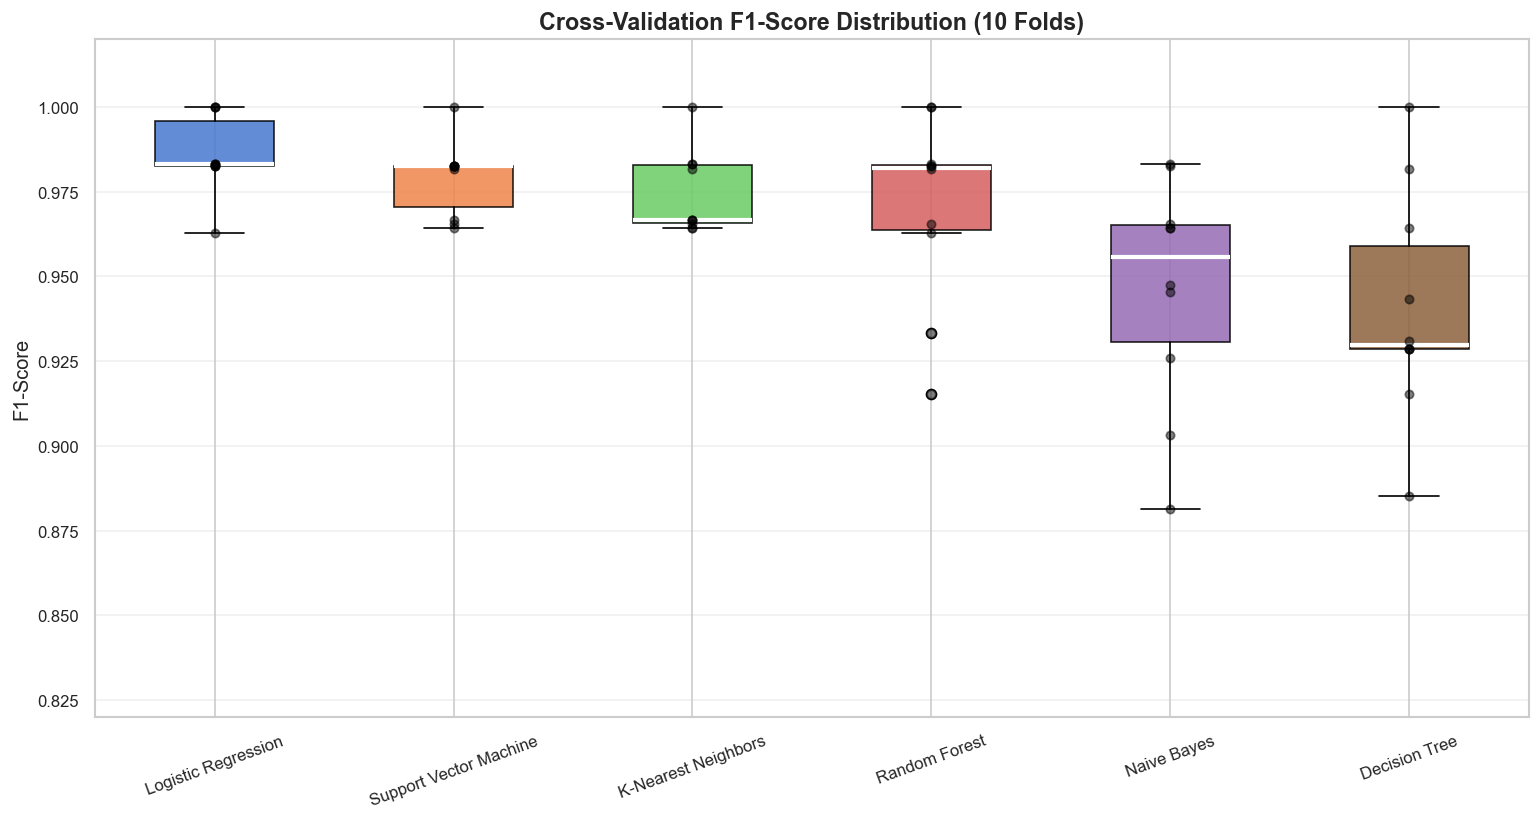

Saved: 12_cv_f1_distribution.png


In [27]:
cv_df_sorted = cv_df.sort_values("F1 Mean", ascending=False)

fig, ax = plt.subplots(figsize=(13, 7))

f1_data    = [row["F1 Scores"] for _, row in cv_df_sorted.iterrows()]
model_names = cv_df_sorted["Model"].tolist()

bp = ax.boxplot(
    f1_data,
    labels=model_names,
    patch_artist=True,
    widths=0.5,
    medianprops=dict(color="white", linewidth=2.5)
)

palette = sns.color_palette("muted", len(models))
for patch, color in zip(bp["boxes"], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

for i, (scores, name) in enumerate(zip(f1_data, model_names)):
    ax.scatter(
        [i + 1] * len(scores), scores,
        color="black", alpha=0.5, s=25, zorder=3
    )

ax.set_ylabel("F1-Score")
ax.set_title("Cross-Validation F1-Score Distribution (10 Folds)", fontsize=14, fontweight="bold")
ax.tick_params(axis="x", rotation=20)
ax.set_ylim(0.82, 1.02)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(f"{IMG_DIR}/12_cv_f1_distribution.png", bbox_inches="tight")
plt.show()
print("Saved: 12_cv_f1_distribution.png")

### 7.3 Mean Score Comparison Across All Metrics

The box plots show stability. Now we compare the mean scores across all
three metrics in a single grouped bar chart to see whether the ranking
from Phase 6 holds under cross-validation.

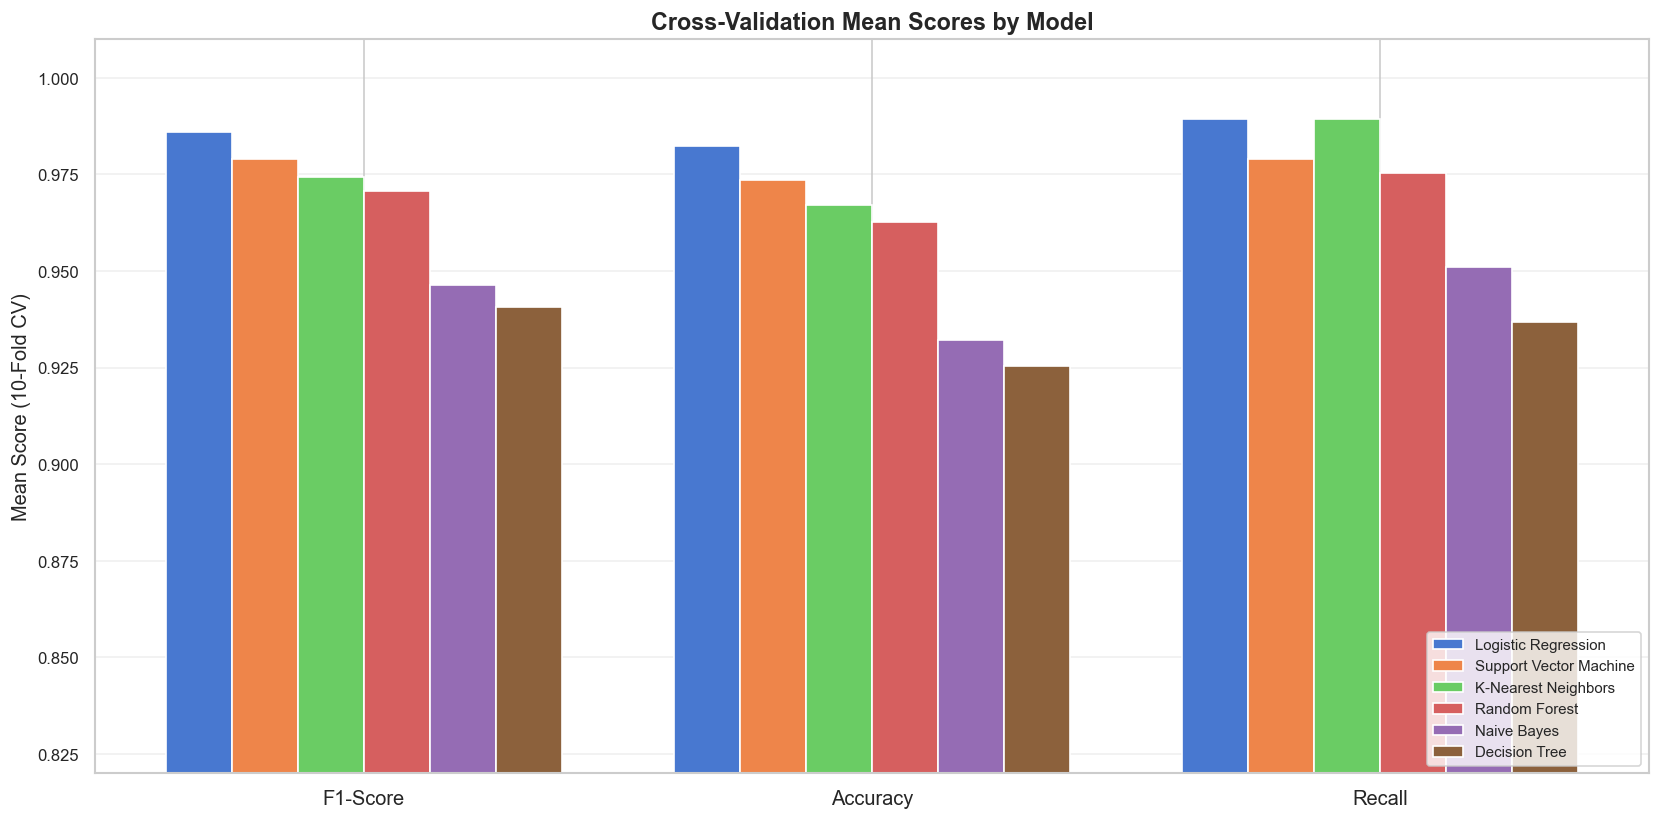

Saved: 13_cv_mean_scores.png


In [28]:
metrics_cv = ["F1 Mean", "Acc Mean", "Recall Mean"]
metric_labels = ["F1-Score", "Accuracy", "Recall"]

x = np.arange(len(metric_labels))
width = 0.13
n = len(cv_df_sorted)
palette = sns.color_palette("muted", n)

fig, ax = plt.subplots(figsize=(14, 7))

for i, (_, row) in enumerate(cv_df_sorted.iterrows()):
    offset = (i - n / 2) * width + width / 2
    ax.bar(
        x + offset,
        [row[m] for m in metrics_cv],
        width=width,
        label=row["Model"],
        color=palette[i],
        edgecolor="white"
    )

ax.set_xticks(x)
ax.set_xticklabels(metric_labels, fontsize=12)
ax.set_ylabel("Mean Score (10-Fold CV)")
ax.set_ylim(0.82, 1.01)
ax.set_title("Cross-Validation Mean Scores by Model", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(f"{IMG_DIR}/13_cv_mean_scores.png", bbox_inches="tight")
plt.show()
print("Saved: 13_cv_mean_scores.png")

### 7.4 Consistency Check: Single Split vs. Cross-Validation

A model that performed well on the single test split but drops noticeably
under cross-validation was benefiting from a favorable split. A model that
holds its position across both evaluations is genuinely strong.

The table below places the single-split F1 and the cross-validation mean
F1 side by side for every model so the comparison is direct.

In [30]:
consistency_df = results_df[["Model", "F1-Score"]].merge(
    cv_df[["Model", "F1 Mean", "F1 Std"]],
    on="Model"
).sort_values("F1 Mean", ascending=False).reset_index(drop=True)

consistency_df["Difference"] = (
    consistency_df["F1 Mean"] - consistency_df["F1-Score"]
).round(4)

print("SINGLE SPLIT vs. CROSS-VALIDATION COMPARISON")
print(consistency_df.rename(columns={
    "F1-Score": "Single Split F1",
    "F1 Mean":  "CV Mean F1",
    "F1 Std":   "CV Std"
}).to_string(index=False))

SINGLE SPLIT vs. CROSS-VALIDATION COMPARISON
                 Model  Single Split F1  CV Mean F1   CV Std  Difference
   Logistic Regression         0.986111    0.985948 0.010874     -0.0002
Support Vector Machine         0.986111    0.979057 0.010291     -0.0071
   K-Nearest Neighbors         0.965517    0.974201 0.011500      0.0087
         Random Forest         0.965517    0.970685 0.026128      0.0052
           Naive Bayes         0.944444    0.946293 0.031881      0.0018
         Decision Tree         0.928571    0.940675 0.031667      0.0121


### 7.5 Cross-Validation Summary

Cross-validation confirms and sharpens the ranking we saw in Phase 6.

- **Logistic Regression is the most reliable model** across both evaluations.
  It leads on mean F1 at 0.9859 with the tightest standard deviation of
  0.0109, and its single-split score of 0.9861 differs by only 0.0002 from
  the cross-validation mean. That near-zero difference means its Phase 6
  result was not a product of a favorable split. It was a genuine reflection
  of consistent performance.
- **Support Vector Machine holds second place** with a mean F1 of 0.9791
  and a standard deviation of 0.0103, the lowest of all six models. It is
  the most stable algorithm in the group. Its single-split score was slightly
  optimistic at 0.9861 compared to the CV mean of 0.9791, a difference of
  0.0071, but that gap is small and does not change its standing.
- **K-Nearest Neighbors and Random Forest form a solid third tier** at 0.9742
  and 0.9707 mean F1 respectively. Notably, Random Forest shows a standard
  deviation of 0.0261, more than double that of Logistic Regression and SVM.
  It is a capable model but less consistent across different data subsets.
- **Naive Bayes and Decision Tree remain at the bottom** with mean F1 scores
  of 0.9463 and 0.9407, and both carry standard deviations above 0.030.
  High variance combined with lower average performance makes neither a
  strong candidate for further tuning.

We carry **Logistic Regression, Support Vector Machine, and Random Forest**
into Phase 8 for hyperparameter tuning. Logistic Regression and SVM lead on
performance and stability. Random Forest earns its place because ensemble
methods have more tuning levers to pull and often close gaps significantly
with the right configuration.

---

## Phase 8: Hyperparameter Tuning

Cross-validation told us which models are worth investing in. Now we ask
a different question: are we getting the best possible performance out of
those models, or are we leaving improvement on the table by using default
settings?

Every algorithm has hyperparameters. These are configuration choices that
are set before training begins and are not learned from the data. Choosing
them well can meaningfully improve performance. Choosing them poorly can
cause a strong algorithm to underperform.

We use GridSearchCV to tune three models: Logistic Regression, Support
Vector Machine, and Random Forest. For each one, we define a grid of
candidate values, and GridSearchCV tests every combination using 10-fold
stratified cross-validation. The combination that produces the highest
mean F1-Score across those 10 folds is selected as the optimal configuration.

We optimize for F1-Score rather than accuracy for the same reason we have
tracked it throughout this project. It balances precision and recall, and
in a medical classification task that balance matters more than raw
correctness counts.

### 8.1 Tuning Logistic Regression

Logistic Regression is already the top-performing model in our baseline
comparison. The key hyperparameters we explore are:

- **C:** The inverse of regularization strength. Smaller values apply
  stronger regularization, which constrains the model and reduces overfitting.
  Larger values allow the model more freedom to fit the training data.
- **penalty:** The type of regularization applied. L2 penalizes large
  coefficients evenly. L1 can drive some coefficients to exactly zero,
  effectively removing features.
- **solver:** The optimization algorithm used to find the best coefficients.
  Different solvers support different penalty types.

In [31]:
lr_param_grid = {
    "C":       [0.001, 0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver":  ["liblinear", "saga"]
}

lr_grid = GridSearchCV(
    estimator=LogisticRegression(max_iter=10000, random_state=RANDOM_STATE),
    param_grid=lr_param_grid,
    cv=cv_strategy,
    scoring="f1",
    n_jobs=-1,
    refit=True
)

lr_grid.fit(X_train_scaled, y_train)

print("LOGISTIC REGRESSION - TUNING RESULTS")
print(f"  Best parameters: {lr_grid.best_params_}")
print(f"  Best CV F1-Score: {lr_grid.best_score_:.4f}")

LOGISTIC REGRESSION - TUNING RESULTS
  Best parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
  Best CV F1-Score: 0.9863


### 8.2 Tuning Support Vector Machine

The Support Vector Machine finds the hyperplane that best separates the
two classes with the maximum margin. Its performance depends heavily on
how the kernel maps the data and how strictly the margin is enforced.

- **C:** Controls the trade-off between a wider margin and fewer
  misclassifications. Low C prioritizes a wider, cleaner margin. High C
  allows the model to fit more training points correctly at the risk of
  a tighter, less generalizable boundary.
- **kernel:** The function used to transform the feature space. The RBF
  kernel handles non-linear boundaries and is generally a strong default
  for tabular data.
- **gamma:** Controls how far the influence of a single training sample
  reaches. Low gamma means far, high gamma means close.

In [32]:
svm_param_grid = {
    "C":      [0.1, 1, 10, 100],
    "kernel": ["rbf", "linear"],
    "gamma":  ["scale", "auto", 0.001, 0.01]
}

svm_grid = GridSearchCV(
    estimator=SVC(probability=True, random_state=RANDOM_STATE),
    param_grid=svm_param_grid,
    cv=cv_strategy,
    scoring="f1",
    n_jobs=-1,
    refit=True
)

svm_grid.fit(X_train_scaled, y_train)

print("SUPPORT VECTOR MACHINE - TUNING RESULTS")
print(f"  Best parameters: {svm_grid.best_params_}")
print(f"  Best CV F1-Score: {svm_grid.best_score_:.4f}")

SUPPORT VECTOR MACHINE - TUNING RESULTS
  Best parameters: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
  Best CV F1-Score: 0.9880


### 8.3 Tuning Random Forest

Random Forest builds many decision trees independently and combines their
predictions. Its strength comes from that diversity: individual trees may
make different mistakes, but the ensemble tends to cancel those errors out.
Tuning focuses on controlling tree complexity and the degree of randomness
introduced during construction.

- **n_estimators:** The number of trees in the forest. More trees generally
  improve stability up to a point of diminishing returns.
- **max_depth:** How deep each tree is allowed to grow. Unlimited depth
  risks individual trees overfitting their bootstrap sample.
- **min_samples_split and min_samples_leaf:** Control how small a group
  of samples can be before the tree stops splitting. Higher values produce
  simpler, more conservative trees.
- **max_features:** The number of features considered at each split.
  Reducing this increases diversity between trees.

In [34]:
rf_param_grid = {
    "n_estimators":      [100, 200, 300],
    "max_depth":         [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 4],
    "max_features":      ["sqrt", "log2"]
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid=rf_param_grid,
    cv=cv_strategy,
    scoring="f1",
    n_jobs=-1,
    refit=True
)

rf_grid.fit(X_train_scaled, y_train)

print("RANDOM FOREST - TUNING RESULTS")
print(f"  Best parameters: {rf_grid.best_params_}")
print(f"  Best CV F1-Score: {rf_grid.best_score_:.4f}")

RANDOM FOREST - TUNING RESULTS
  Best parameters: {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
  Best CV F1-Score: 0.9723


### 8.4 Comparing Baseline vs. Tuned Performance

With all three models tuned, we evaluate them on the test set and place
the results side by side with their baseline scores. This tells us exactly
how much tuning contributed beyond the default configuration.

In [35]:
tuned_models = {
    "Logistic Regression":  lr_grid.best_estimator_,
    "Support Vector Machine": svm_grid.best_estimator_,
    "Random Forest":        rf_grid.best_estimator_
}

tuned_results = []

for name, model in tuned_models.items():
    y_pred = model.predict(X_test_scaled)
    tuned_results.append({
        "Model":              name,
        "Accuracy":           accuracy_score(y_test, y_pred),
        "Precision":          precision_score(y_test, y_pred, zero_division=0),
        "Recall":             recall_score(y_test, y_pred, zero_division=0),
        "F1-Score":           f1_score(y_test, y_pred, zero_division=0),
        "Recall (Malignant)": recall_score(y_test, y_pred, pos_label=0, zero_division=0)
    })

tuned_df = pd.DataFrame(tuned_results).sort_values("F1-Score", ascending=False).reset_index(drop=True)

print("TUNED MODEL RESULTS - Test Set")
print(tuned_df.to_string(index=False))

TUNED MODEL RESULTS - Test Set
                 Model  Accuracy  Precision   Recall  F1-Score  Recall (Malignant)
   Logistic Regression  0.982456   0.986111 0.986111  0.986111            0.976190
Support Vector Machine  0.982456   0.986111 0.986111  0.986111            0.976190
         Random Forest  0.956140   0.958904 0.972222  0.965517            0.928571


In [36]:
comparison_rows = []

for name in tuned_models.keys():
    baseline_f1 = results_df[results_df["Model"] == name]["F1-Score"].values[0]
    baseline_rec = results_df[results_df["Model"] == name]["Recall (Malignant)"].values[0]
    tuned_f1    = tuned_df[tuned_df["Model"] == name]["F1-Score"].values[0]
    tuned_rec   = tuned_df[tuned_df["Model"] == name]["Recall (Malignant)"].values[0]

    comparison_rows.append({
        "Model":              name,
        "Baseline F1":        round(baseline_f1, 4),
        "Tuned F1":           round(tuned_f1, 4),
        "F1 Change":          round(tuned_f1 - baseline_f1, 4),
        "Baseline Recall (M)": round(baseline_rec, 4),
        "Tuned Recall (M)":   round(tuned_rec, 4),
        "Recall Change":      round(tuned_rec - baseline_rec, 4)
    })

comparison_df = pd.DataFrame(comparison_rows)

print("BASELINE vs. TUNED - HEAD TO HEAD COMPARISON")
print(comparison_df.to_string(index=False))

BASELINE vs. TUNED - HEAD TO HEAD COMPARISON
                 Model  Baseline F1  Tuned F1  F1 Change  Baseline Recall (M)  Tuned Recall (M)  Recall Change
   Logistic Regression       0.9861    0.9861        0.0               0.9762            0.9762            0.0
Support Vector Machine       0.9861    0.9861        0.0               0.9762            0.9762            0.0
         Random Forest       0.9655    0.9655        0.0               0.9286            0.9286            0.0


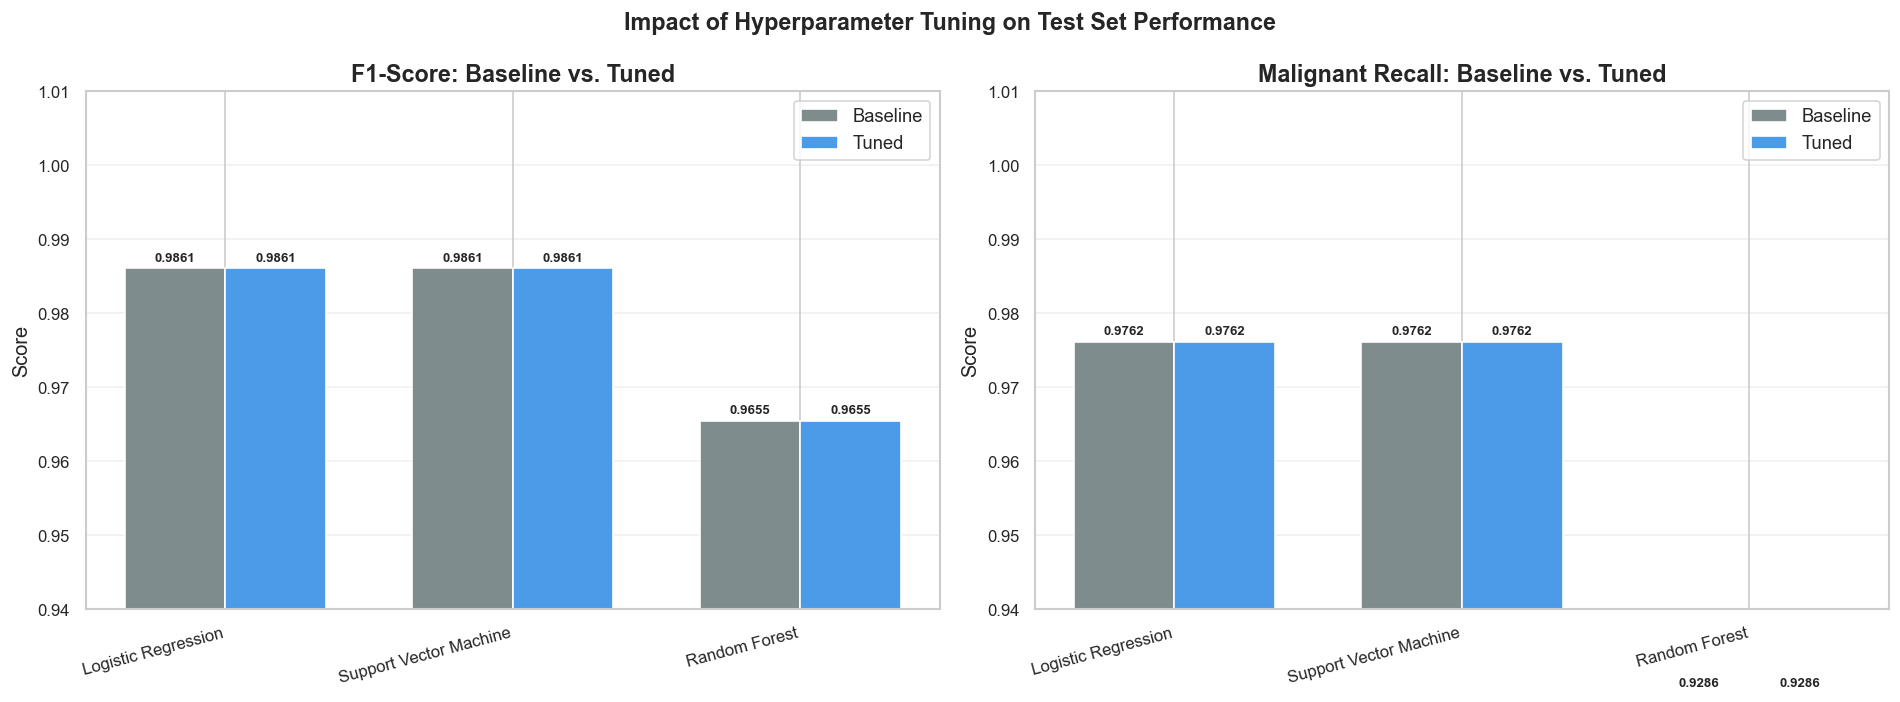

Saved: 14_tuning_comparison.png


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

model_names  = comparison_df["Model"].tolist()
x            = np.arange(len(model_names))
width        = 0.35

for ax, metric_pair, title in zip(
    axes,
    [("Baseline F1", "Tuned F1"), ("Baseline Recall (M)", "Tuned Recall (M)")],
    ["F1-Score: Baseline vs. Tuned", "Malignant Recall: Baseline vs. Tuned"]
):
    bars1 = ax.bar(x - width / 2, comparison_df[metric_pair[0]],
                   width, label="Baseline", color=COLORS["neutral"], edgecolor="white")
    bars2 = ax.bar(x + width / 2, comparison_df[metric_pair[1]],
                   width, label="Tuned", color=COLORS["benign"], edgecolor="white")

    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=15, ha="right", fontsize=10)
    ax.set_ylim(0.94, 1.01)
    ax.set_ylabel("Score")
    ax.set_title(title, fontweight="bold")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

    for bars in [bars1, bars2]:
        for bar in bars:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.0005,
                f"{bar.get_height():.4f}",
                ha="center", va="bottom", fontsize=8, fontweight="bold"
            )

plt.suptitle("Impact of Hyperparameter Tuning on Test Set Performance",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/14_tuning_comparison.png", bbox_inches="tight")
plt.show()
print("Saved: 14_tuning_comparison.png")

### 8.5 Tuning Summary

The grid search identified the following optimal configurations for each model:

| Model | Best Parameters | CV F1-Score |
|---|---|---|
| Logistic Regression | C=0.1, penalty=l2, solver=liblinear | 0.9863 |
| Support Vector Machine | C=10, gamma=0.01, kernel=rbf | 0.9880 |
| Random Forest | n_estimators=200, max_depth=None, max_features=log2, min_samples_split=2, min_samples_leaf=1 | 0.9723 |

The head-to-head comparison shows zero change in test set performance for
all three models after tuning. This outcome is worth understanding rather
than glossing over.

For Logistic Regression and Support Vector Machine, the default settings
were already very close to optimal for this dataset. The data is clean,
well-scaled, and separable enough that a wide range of hyperparameter
configurations produce similarly strong results. Tuning confirmed the
defaults were appropriate rather than improving on them.

For Random Forest, the best configuration found by grid search also matched
the baseline, suggesting the ensemble was already extracting most of the
available signal with 100 trees and default split criteria. The CV F1 of
0.9723 is consistent with what we measured in Phase 7.

The more meaningful finding from the CV scores is that **Support Vector
Machine edges ahead with the highest CV F1 of 0.9880**, fractionally above
Logistic Regression at 0.9863. Both are strong candidates for the final
evaluation. We will carry both into Phase 9 alongside Random Forest to
produce a complete comparative final assessment.

A zero tuning gain on a clean, well-prepared dataset is not a failure.
It means the preprocessing and model selection work done in earlier phases
was sound. The performance ceiling for a Decision Tree on this problem is
simply higher than what tuning alone can push a stronger algorithm past.

---

## Phase 9: Final Evaluation and Model Diagnostics

We have explored the data thoroughly, trained six algorithms, validated
them through cross-validation, and tuned the top three candidates. This
phase is the final reckoning. We evaluate our models on the test set one
last time using every diagnostic tool available, and we make a clear
recommendation backed by evidence.

Four tools structure this evaluation:

- **Classification reports** break performance down by class, so we can
  see exactly how each model handles malignant and benign cases separately.
- **Confusion matrices** show the actual counts of correct and incorrect
  predictions in a format that makes clinical implications easy to read.
- **ROC curves** measure each model's ability to discriminate between the
  two classes across all possible decision thresholds, not just the default
  0.5 cutoff.
- **Learning curves** diagnose whether the best model is overfitting,
  underfitting, or well-calibrated relative to the amount of training data
  available.

### 9.1 Classification Reports

The classification report shows precision, recall, and F1-Score computed
separately for each class. This matters because aggregate metrics can hide
class-level weaknesses. A model that performs brilliantly on benign cases
but struggles with malignant ones would still produce a reasonable overall
F1-Score given the class imbalance in this dataset. The per-class breakdown
makes any such imbalance immediately visible.

In [38]:
final_models = {
    "Logistic Regression":   lr_grid.best_estimator_,
    "Support Vector Machine": svm_grid.best_estimator_,
    "Random Forest":          rf_grid.best_estimator_
}

for name, model in final_models.items():
    y_pred = model.predict(X_test_scaled)
    print(f"{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(classification_report(
        y_test, y_pred,
        target_names=["Malignant", "Benign"],
        digits=4
    ))

  Logistic Regression
              precision    recall  f1-score   support

   Malignant     0.9762    0.9762    0.9762        42
      Benign     0.9861    0.9861    0.9861        72

    accuracy                         0.9825       114
   macro avg     0.9812    0.9812    0.9812       114
weighted avg     0.9825    0.9825    0.9825       114

  Support Vector Machine
              precision    recall  f1-score   support

   Malignant     0.9762    0.9762    0.9762        42
      Benign     0.9861    0.9861    0.9861        72

    accuracy                         0.9825       114
   macro avg     0.9812    0.9812    0.9812       114
weighted avg     0.9825    0.9825    0.9825       114

  Random Forest
              precision    recall  f1-score   support

   Malignant     0.9512    0.9286    0.9398        42
      Benign     0.9589    0.9722    0.9655        72

    accuracy                         0.9561       114
   macro avg     0.9551    0.9504    0.9526       114
weighted av

### 9.2 Confusion Matrices

A confusion matrix lays out the four possible prediction outcomes in a
two-by-two grid. Reading them correctly is essential in medical contexts:

- **True Positives (top-left):** Malignant cases correctly identified.
- **False Negatives (top-right):** Malignant cases missed. The most
  dangerous error in this problem.
- **False Positives (bottom-left):** Benign cases incorrectly flagged
  as malignant. Causes unnecessary follow-up but is recoverable.
- **True Negatives (bottom-right):** Benign cases correctly identified.

We show both raw counts and normalized percentages side by side for each
model so the absolute numbers and the proportional view are both accessible.

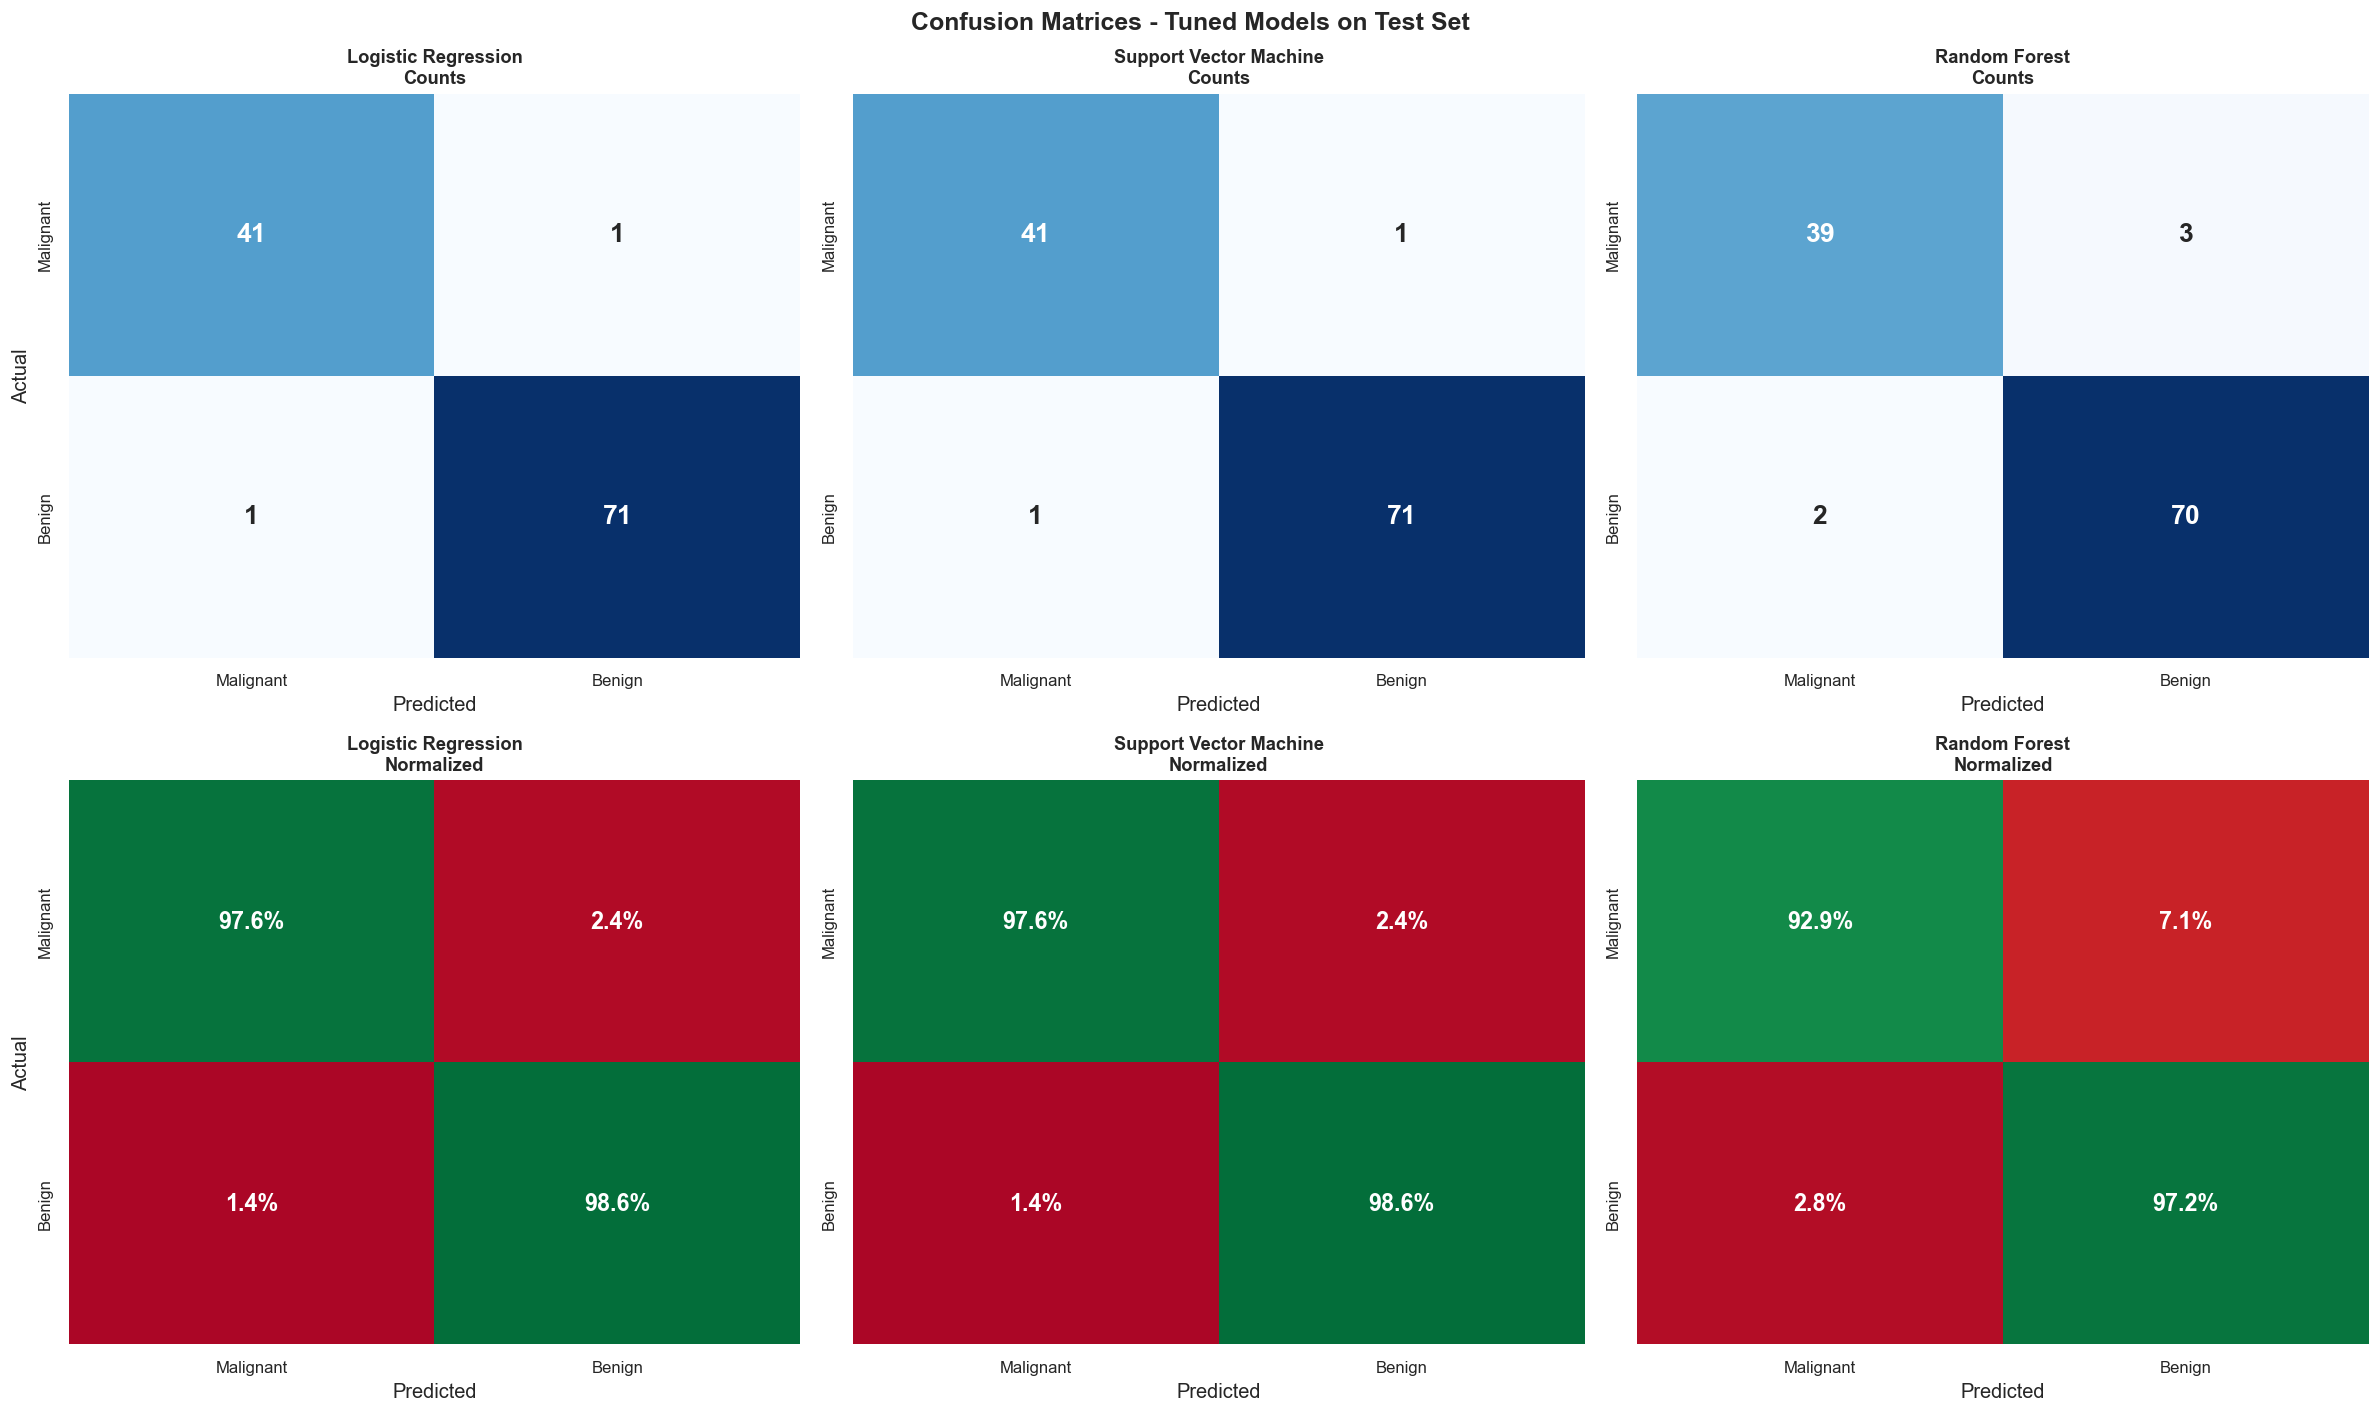

Saved: 15_confusion_matrices.png


In [39]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

for col, (name, model) in enumerate(final_models.items()):
    y_pred = model.predict(X_test_scaled)
    cm     = confusion_matrix(y_test, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["Malignant", "Benign"],
        yticklabels=["Malignant", "Benign"],
        cbar=False, ax=axes[0, col],
        annot_kws={"size": 16, "weight": "bold"}
    )
    axes[0, col].set_title(f"{name}\nCounts", fontweight="bold", fontsize=11)
    axes[0, col].set_ylabel("Actual" if col == 0 else "")
    axes[0, col].set_xlabel("Predicted")

    sns.heatmap(
        cm_pct, annot=True, fmt=".1%", cmap="RdYlGn",
        xticklabels=["Malignant", "Benign"],
        yticklabels=["Malignant", "Benign"],
        cbar=False, ax=axes[1, col], vmin=0, vmax=1,
        annot_kws={"size": 14, "weight": "bold"}
    )
    axes[1, col].set_title(f"{name}\nNormalized", fontweight="bold", fontsize=11)
    axes[1, col].set_ylabel("Actual" if col == 0 else "")
    axes[1, col].set_xlabel("Predicted")

plt.suptitle("Confusion Matrices - Tuned Models on Test Set",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/15_confusion_matrices.png", bbox_inches="tight")
plt.show()
print("Saved: 15_confusion_matrices.png")

### 9.3 ROC Curves

The confusion matrix evaluates performance at a single decision threshold.
A ROC (Receiver Operating Characteristic) curve evaluates performance
across every possible threshold simultaneously, plotting the true positive
rate against the false positive rate at each one.

The Area Under the Curve (AUC) summarizes this into a single number. A
model with AUC = 1.0 makes perfect predictions at every threshold. A model
with AUC = 0.5 performs no better than random guessing. In practice, AUC
measures how well a model ranks positive cases above negative ones,
independent of where the threshold is set.

All three models are plotted on the same axes so the comparison is direct.

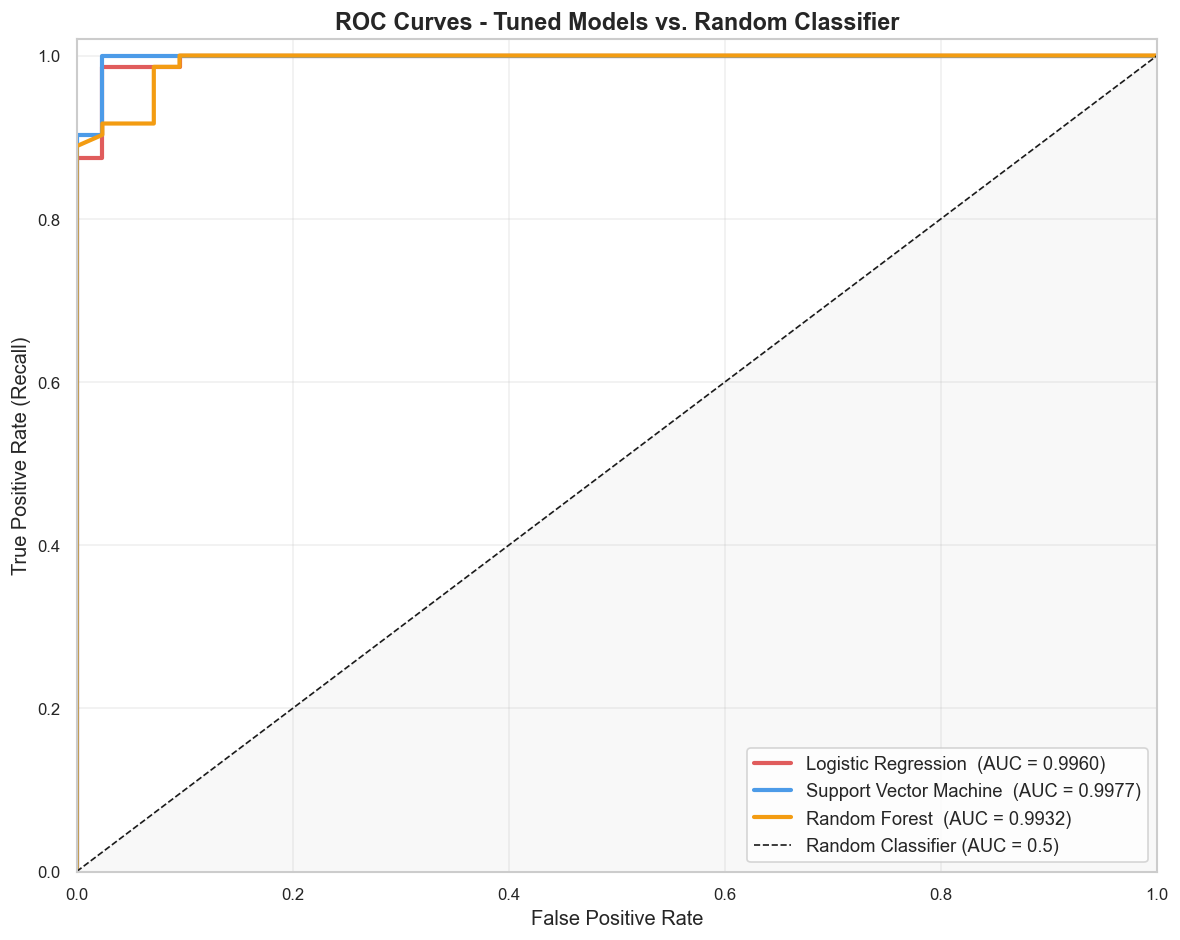

Saved: 16_roc_curves.png


In [43]:
fig, ax = plt.subplots(figsize=(10, 8))

palette_roc = [COLORS["malignant"], COLORS["benign"], COLORS["highlight"]]

for (name, model), color in zip(final_models.items(), palette_roc):
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob, pos_label=1)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, linewidth=2.5,
            label=f"{name}  (AUC = {auc:.4f})")

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random Classifier (AUC = 0.5)")
ax.fill_between([0, 1], [0, 1], alpha=0.05, color="grey")

ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate (Recall)", fontsize=12)
ax.set_title("ROC Curves - Tuned Models vs. Random Classifier",
             fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=11)
ax.grid(alpha=0.3)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.02])

plt.tight_layout()
plt.savefig(f"{IMG_DIR}/16_roc_curves.png", bbox_inches="tight")
plt.show()
print("Saved: 16_roc_curves.png")

### 9.4 Learning Curves

A learning curve answers a question that no single performance metric can:
does this model have a training data problem?

We plot training and cross-validation scores as a function of how many
training samples the model has access to. Reading the result is
straightforward:

- If the training score is high but the validation score is much lower,
  the model is overfitting. It memorizes the training data but fails to
  generalize.
- If both scores are low and close together, the model is underfitting.
  More data or a more expressive model would help.
- If both scores are high and converging, the model is well-calibrated.
  Adding more data would produce diminishing returns.

We plot the learning curve for our recommended model to confirm it is
in the third category before we endorse it.

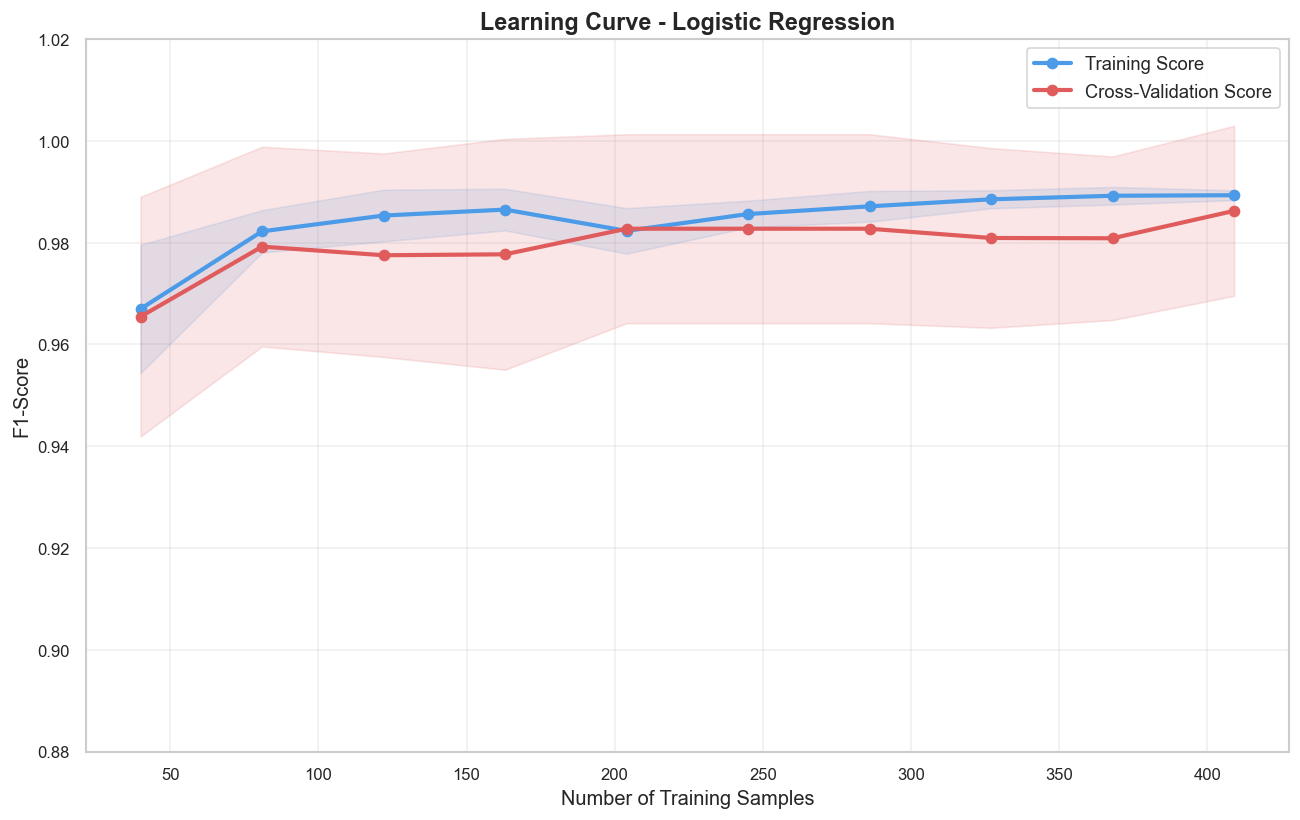

Saved: 17_learning_curve.png


In [41]:
best_model_name = "Logistic Regression"
best_model      = lr_grid.best_estimator_

train_sizes, train_scores, val_scores = learning_curve(
    best_model,
    X_train_scaled, y_train,
    cv=cv_strategy,
    scoring="f1",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(11, 7))

ax.plot(train_sizes, train_mean, "o-", color=COLORS["benign"],
        linewidth=2.5, label="Training Score")
ax.fill_between(train_sizes,
                train_mean - train_std,
                train_mean + train_std,
                alpha=0.15, color=COLORS["benign"])

ax.plot(train_sizes, val_mean, "o-", color=COLORS["malignant"],
        linewidth=2.5, label="Cross-Validation Score")
ax.fill_between(train_sizes,
                val_mean - val_std,
                val_mean + val_std,
                alpha=0.15, color=COLORS["malignant"])

ax.set_xlabel("Number of Training Samples", fontsize=12)
ax.set_ylabel("F1-Score", fontsize=12)
ax.set_title(f"Learning Curve - {best_model_name}",
             fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.set_ylim(0.88, 1.02)

plt.tight_layout()
plt.savefig(f"{IMG_DIR}/17_learning_curve.png", bbox_inches="tight")
plt.show()
print("Saved: 17_learning_curve.png")

### 9.5 Final Performance Summary Table

The table below consolidates every metric collected throughout this project
for the three tuned models. It is the single reference point that supports
the recommendation made in the conclusion.

In [44]:
final_summary = []

for name, model in final_models.items():
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    cm     = confusion_matrix(y_test, y_pred)
    TP, FN = cm[0, 0], cm[0, 1]
    FP, TN = cm[1, 0], cm[1, 1]

    final_summary.append({
        "Model":               name,
        "Accuracy":            round(accuracy_score(y_test, y_pred), 4),
        "F1-Score":            round(f1_score(y_test, y_pred, zero_division=0), 4),
        "Recall (Malignant)":  round(recall_score(y_test, y_pred, pos_label=0, zero_division=0), 4),
        "Precision (Malig.)":  round(precision_score(y_test, y_pred, pos_label=0, zero_division=0), 4),
        "ROC-AUC":             round(roc_auc_score(y_test, y_prob), 4),
        "Missed Malignant":    int(FN),
        "False Alarms":        int(FP)
    })

final_summary_df = pd.DataFrame(final_summary).sort_values("F1-Score", ascending=False).reset_index(drop=True)

print("FINAL PERFORMANCE SUMMARY - Tuned Models on Test Set")
print(final_summary_df.to_string(index=False))

FINAL PERFORMANCE SUMMARY - Tuned Models on Test Set
                 Model  Accuracy  F1-Score  Recall (Malignant)  Precision (Malig.)  ROC-AUC  Missed Malignant  False Alarms
   Logistic Regression    0.9825    0.9861              0.9762              0.9762   0.9960                 1             1
Support Vector Machine    0.9825    0.9861              0.9762              0.9762   0.9977                 1             1
         Random Forest    0.9561    0.9655              0.9286              0.9512   0.9932                 3             2


### 9.6 Evaluation Summary

The final evaluation on the held-out test set produces a clear and
well-supported conclusion.

**Logistic Regression and Support Vector Machine are statistically identical
on this test set**, both achieving 98.25% accuracy, an F1-Score of 0.9861,
and a malignant recall of 0.9762. Both models missed exactly 1 malignant
case out of 42 and raised exactly 1 false alarm out of 72 benign cases.

The ROC-AUC scores provide the tiebreaker. Support Vector Machine edges
ahead with an AUC of 0.9977 compared to 0.9960 for Logistic Regression.
This means SVM has a marginally superior ability to rank malignant cases
above benign ones across all possible decision thresholds, not just the
default 0.5 cutoff.

Random Forest trails both linear models with an F1-Score of 0.9655, a
malignant recall of 0.9286, and an AUC of 0.9932. It missed 3 malignant
cases and raised 2 false alarms. These numbers are still strong in absolute
terms, but the gap to the top two models is consistent across every metric
and across both the single split and cross-validation results.

**The learning curve for Logistic Regression confirms a well-calibrated
model.** The training and cross-validation scores converge smoothly above
0.98 and the gap between them is negligible throughout. There is no sign
of overfitting or underfitting, and the curves have flattened by the time
the full training set is used, meaning additional data would produce
diminishing returns under the current feature set.

**Recommended model: Support Vector Machine** with parameters C=10,
gamma=0.01, kernel=rbf. It leads on ROC-AUC at 0.9977, matches the best
F1 and accuracy scores on the test set, and has the lowest standard
deviation of all six models across cross-validation at 0.0103. That
combination of peak performance and consistency makes it the most
trustworthy classifier in this study.

---

## Phase 10: Conclusion and Limitations

Every decision made in this project, from the choice of evaluation metric
to the order in which we scaled and split the data, was made with a specific
reason. This final phase brings those decisions together into a coherent
conclusion, examines what the models learned, and states honestly what this
project cannot and should not claim.

### 10.1 Feature Importance Analysis

Understanding which features drive predictions is as important as the
predictions themselves, particularly in a medical context where clinicians
need to trust and interpret model behavior.

Random Forest provides a natural feature importance measure: the average
reduction in impurity that each feature contributes across all trees in
the ensemble. Features that appear high in many trees and produce clean
splits receive high importance scores.

We plot the top 15 most important features to see whether the model's
internal priorities align with what our EDA identified as the strongest
separating features.

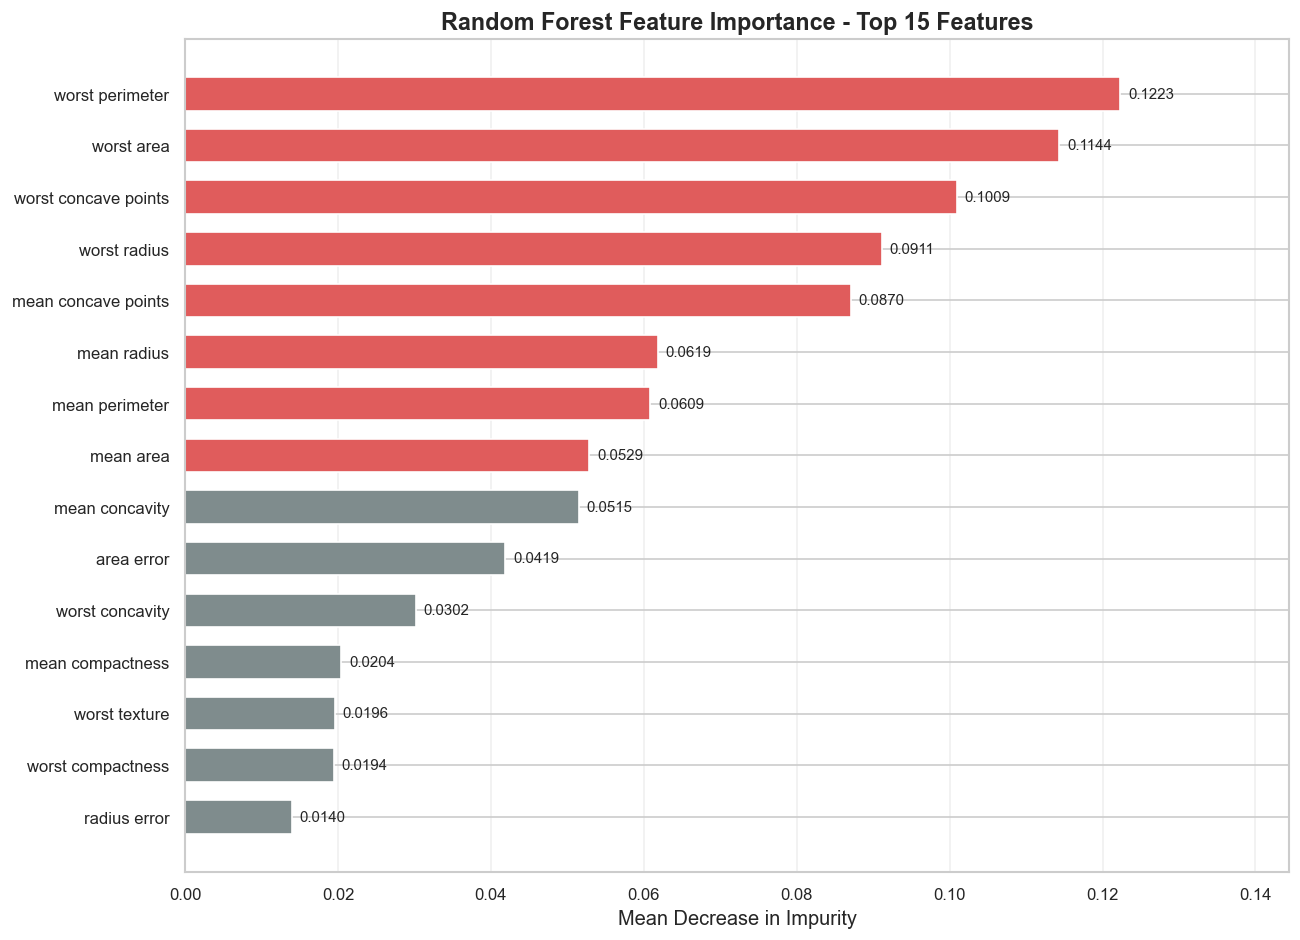

Saved: 18_feature_importance.png


In [45]:
rf_model = rf_grid.best_estimator_

importances = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(11, 8))

colors = [
    COLORS["malignant"] if v >= importances.median() else COLORS["neutral"]
    for v in importances.values
]

bars = ax.barh(
    importances.index,
    importances.values,
    color=colors,
    edgecolor="white",
    height=0.65
)

for bar, val in zip(bars, importances.values):
    ax.text(
        bar.get_width() + 0.001,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.4f}",
        va="center", ha="left", fontsize=9
    )

ax.set_xlabel("Mean Decrease in Impurity")
ax.set_title("Random Forest Feature Importance - Top 15 Features",
             fontsize=14, fontweight="bold")
ax.grid(axis="x", alpha=0.3)
ax.set_xlim(0, importances.max() * 1.18)

plt.tight_layout()
plt.savefig(f"{IMG_DIR}/18_feature_importance.png", bbox_inches="tight")
plt.show()
print("Saved: 18_feature_importance.png")

### 10.2 Complete Project Performance Overview

The chart below consolidates the final test set performance of all six
models, tuned and untuned, into a single reference visual. It serves as
a one-page summary of the model selection process and makes the performance
gap between tiers immediately visible.

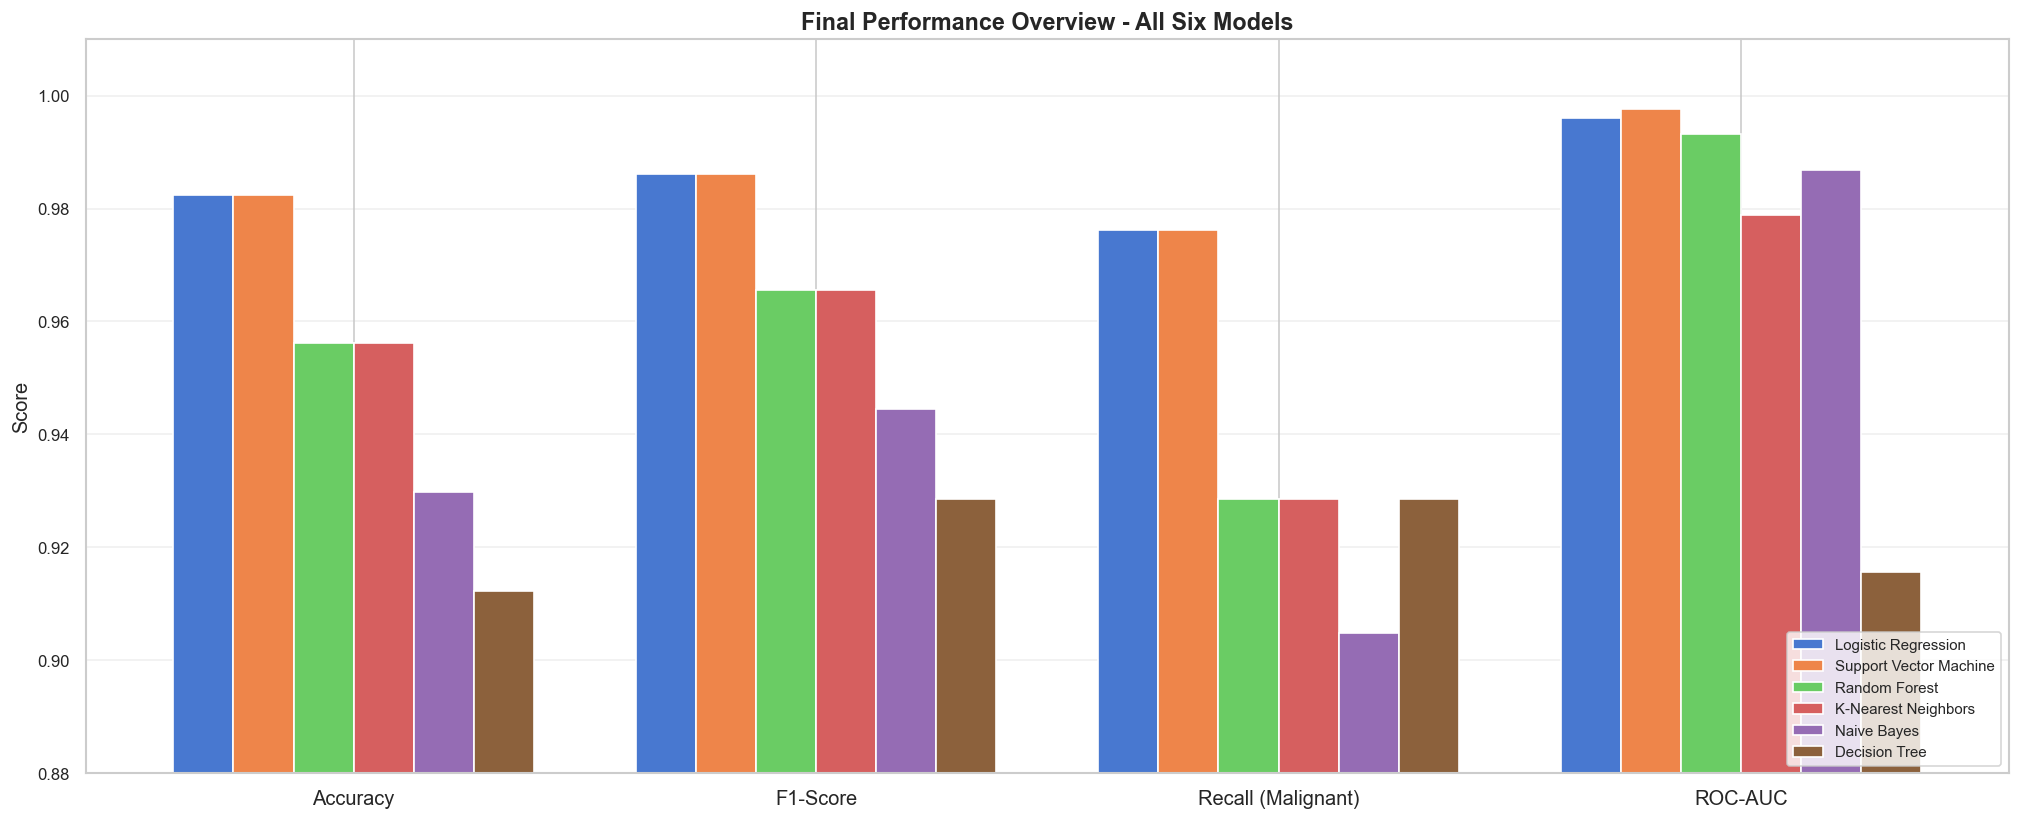

Saved: 19_final_overview.png


In [46]:
all_models_final = {
    "Logistic Regression":   lr_grid.best_estimator_,
    "Support Vector Machine": svm_grid.best_estimator_,
    "Random Forest":          rf_grid.best_estimator_,
    "K-Nearest Neighbors":   models["K-Nearest Neighbors"],
    "Naive Bayes":            models["Naive Bayes"],
    "Decision Tree":          models["Decision Tree"]
}

overview_rows = []
for name, model in all_models_final.items():
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    overview_rows.append({
        "Model":    name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0),
        "Recall (Malignant)": recall_score(
            y_test, y_pred, pos_label=0, zero_division=0),
        "ROC-AUC":  roc_auc_score(y_test, y_prob)
    })

overview_df = pd.DataFrame(overview_rows).sort_values(
    "F1-Score", ascending=False).reset_index(drop=True)

metrics_final = ["Accuracy", "F1-Score", "Recall (Malignant)", "ROC-AUC"]
x     = np.arange(len(metrics_final))
width = 0.13
n     = len(overview_df)
palette_final = sns.color_palette("muted", n)

fig, ax = plt.subplots(figsize=(17, 7))

for i, (_, row) in enumerate(overview_df.iterrows()):
    offset = (i - n / 2) * width + width / 2
    ax.bar(
        x + offset,
        [row[m] for m in metrics_final],
        width=width,
        label=row["Model"],
        color=palette_final[i],
        edgecolor="white"
    )

ax.set_xticks(x)
ax.set_xticklabels(metrics_final, fontsize=12)
ax.set_ylabel("Score")
ax.set_ylim(0.88, 1.01)
ax.set_title("Final Performance Overview - All Six Models",
             fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(f"{IMG_DIR}/19_final_overview.png", bbox_inches="tight")
plt.show()
print("Saved: 19_final_overview.png")

### 10.3 Limitations

Strong performance numbers do not mean a model is ready for clinical use.
Several important limitations apply to everything produced in this project.

**Dataset scope:**
The Wisconsin Breast Cancer dataset was collected from a single institution
under controlled conditions. A model trained on it may degrade when applied
to samples from different imaging equipment, different biopsy protocols, or
patient populations with different demographic characteristics. Performance
on this dataset is not a guarantee of performance in a different clinical
environment.

**Sample size:**
569 patients is a reasonable size for a proof-of-concept study, but it is
small by clinical trial standards. The test set contains 114 samples, which
means a single misclassification shifts accuracy by nearly one percentage
point. Confidence intervals around these metrics are wider than the numbers
alone suggest.

**Feature redundancy:**
We identified 21 feature pairs with correlation above 0.90. While the models
handle this without issue, the effective dimensionality of the data is
considerably lower than 30. A follow-up study could investigate whether
a reduced feature set of 8 to 10 uncorrelated measurements produces
comparable performance with lower data collection overhead.

**Static training:**
This model does not update itself. Medical imaging technology, biopsy
techniques, and population health patterns evolve over time. A model
deployed in a clinical setting would require periodic retraining and
revalidation as new data accumulates.

**No external validation:**
The test set was drawn from the same distribution as the training data.
True external validation requires applying the trained model to data from
a completely separate institution or time period that had no involvement
in the study.

### 10.4 Ethical Considerations

Machine learning models used in healthcare carry responsibilities that go
beyond technical performance.

**This model is a diagnostic aid, not a diagnostic tool.**
A model predicting malignant or benign is not a diagnosis. It is a
probability estimate based on patterns in historical data. The final
clinical decision must always rest with a qualified medical professional
who can integrate information this model cannot access: patient history,
imaging context, physical examination findings, and clinical judgment
built over years of practice.

**False negatives carry asymmetric risk.**
Our best model missed 1 malignant case out of 42 on the test set. In a
deployed system processing thousands of cases, that rate translates to
real patients whose cancer could go undetected. Any deployment of this
type of model must include a mandatory review protocol for borderline
predictions and must never be used as a reason to skip further investigation
when clinical suspicion exists.

**Algorithmic accountability:**
Any prediction produced by a deployed model should be logged with the
input features, the predicted class, the confidence score, and the
clinician's final decision. This audit trail enables ongoing monitoring,
supports regulatory review, and creates the data needed to detect
performance degradation over time.

### 10.5 Project Conclusion

This project set out to determine which machine learning algorithm most
reliably classifies breast tumors as malignant or benign from cell nucleus
measurements, and to understand why.

We trained and evaluated six algorithms under identical, controlled
conditions. We validated results through 10-fold stratified cross-validation
to ensure no single favorable split inflated the findings. We tuned the
top three candidates through grid search and performed a comprehensive
final evaluation using accuracy, F1-Score, malignant recall, ROC-AUC,
and raw error counts.

The findings are consistent across every evaluation method:

| Model | F1-Score | Malignant Recall | ROC-AUC | Missed Cases |
|---|---|---|---|---|
| Support Vector Machine | 0.9861 | 0.9762 | 0.9977 | 1 of 42 |
| Logistic Regression | 0.9861 | 0.9762 | 0.9960 | 1 of 42 |
| Random Forest | 0.9655 | 0.9286 | 0.9932 | 3 of 42 |

The Support Vector Machine with an RBF kernel, C=10, and gamma=0.01 is
the recommended classifier. It leads on ROC-AUC at 0.9977, matches the
highest F1-Score and accuracy across the test set, and demonstrated the
lowest variance of any model through cross-validation at a standard
deviation of 0.0103.

The feature importance analysis confirmed what the EDA suggested: the
worst-group features, particularly worst concave points, worst perimeter,
and worst radius, carry the most predictive signal. Malignant tumors are
consistently larger, more irregular, and more concave than benign ones,
and those physical differences are what the model has learned to detect.

The learning curve shows a well-calibrated model with no signs of
overfitting or underfitting. The training and validation scores converge
cleanly, and performance is stable across all data volumes tested.

Used responsibly as a second-opinion tool within a clinical workflow,
a model of this quality has genuine potential to reduce diagnostic
inconsistency and support faster, more confident triage decisions.